AVISO LEGAL — PROPIEDAD INTELECTUAL

Este material es propiedad intelectual exclusiva de Julián David Flórez Sánchez (LinkedIn). Todos los derechos reservados. Queda terminantemente prohibida su copia, reproducción, distribución, adaptación o uso por cualquier persona natural o jurídica, pública o privada, sin autorización expresa y escrita del autor. El incumplimiento de esta disposición acarrea las sanciones civiles y penales previstas en la Ley 23 de 1982, la Decisión Andina 351 de 1993, los artículos 270-272 del Código Penal Colombiano y los tratados internacionales de propiedad intelectual aplicables. Para solicitar autorización: linkedin.com/in/julianflorezdata

# Guía 09: Fundamentos de Procesamiento de Lenguaje Natural con NLTK

## Electiva II - Deep Learning | Tecnológico de Antioquia

---

| Información | Detalle |
|---|---|
| **Objetivo** | Comprender los fundamentos del Procesamiento de Lenguaje Natural (PLN) y aplicar técnicas de preprocesamiento de texto para preparar datos textuales como entrada a modelos de Deep Learning |
| **Conceptos nuevos** | Procesamiento de Lenguaje Natural, tokenización, stopwords, stemming, lematización, Bag of Words (BoW), TF-IDF, n-gramas, nube de palabras, clasificación de texto con representaciones tradicionales |
| **Prerrequisito** | Guía 08 - Introducción a PyTorch |
| **Duración estimada** | 3 horas |
| **Guía** | 9 de 14 |

> **Aviso de evaluación:** Esta guía contiene preguntas y ejercicios que serán evaluados. Las celdas marcadas con requieren tu respuesta escrita. El reto extra 🏆 otorga puntos adicionales.

---

## Contexto del curso

Hasta ahora hemos trabajado con:
- **Datos numéricos tabulares** (Guías 01-04): redes densas (DNN)
- **Imágenes** (Guías 05-06): redes convolucionales (CNN)
- **Series temporales / secuencias** (Guía 07): redes recurrentes (RNN/LSTM)
- **PyTorch** (Guía 08): nuevo framework de Deep Learning

Ahora damos un paso fundamental: **trabajar con texto**. El Procesamiento de Lenguaje Natural (PLN o NLP en inglés) es una de las áreas más activas del Deep Learning y está detrás de tecnologías como ChatGPT, traductores automáticos, asistentes virtuales y análisis de sentimiento.

En esta guía aprenderemos las **bases del preprocesamiento de texto** usando la biblioteca NLTK y representaciones clásicas (BoW, TF-IDF). En las siguientes guías avanzaremos hacia Word Embeddings (Guía 10), modelos secuenciales para texto (Guía 11) y Transformers (Guías 12-13).

---

## 1. Configuración del entorno

Instalamos las bibliotecas necesarias y descargamos los recursos de NLTK.

In [129]:
# Instalación de dependencias
!pip install nltk wordcloud -q

In [130]:
# Descarga de recursos de NLTK
import nltk

nltk.download('punkt')        # Tokenizador de oraciones y palabras
nltk.download('punkt_tab')    # Datos tabulares para tokenización
nltk.download('stopwords')    # Listas de palabras vacías por idioma
nltk.download('wordnet')      # Base de datos léxica para lematización
nltk.download('averaged_perceptron_tagger')  # Etiquetador POS
nltk.download('omw-1.4')      # Open Multilingual WordNet

print("Recursos de NLTK descargados correctamente.")

Recursos de NLTK descargados correctamente.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [131]:
# Importaciones generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
from collections import Counter

# NLTK
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk import ngrams

# Scikit-learn para representaciones de texto
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# WordCloud
from wordcloud import WordCloud

# PyTorch (para la clasificación final)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print(f"NLTK versión: {nltk.__version__}")
print(f"PyTorch versión: {torch.__version__}")
print(f"NumPy versión: {np.__version__}")
print(f"Pandas versión: {pd.__version__}")
print("\n¡Entorno configurado correctamente!")

NLTK versión: 3.9.1
PyTorch versión: 2.10.0+cu128
NumPy versión: 2.0.2
Pandas versión: 2.2.2

¡Entorno configurado correctamente!


---

## 2. Marco teórico: Fundamentos del Procesamiento de Lenguaje Natural

### 2.1 ¿Qué es el Procesamiento de Lenguaje Natural (PLN)?

El **Procesamiento de Lenguaje Natural** (PLN, o NLP por sus siglas en inglés: *Natural Language Processing*) es una rama de la inteligencia artificial que se enfoca en la **interacción entre computadoras y el lenguaje humano**. Su objetivo es permitir que las máquinas comprendan, interpreten y generen texto de manera útil.

#### De imágenes y series temporales a TEXTO

En las guías anteriores trabajamos con datos que tienen una estructura numérica natural:

| Tipo de dato | Estructura | Ejemplo |
|---|---|---|
| Tabular | Matriz de números | Precio, edad, temperatura |
| Imágenes | Matrices de píxeles (0-255) | Fotos, radiografías |
| Series temporales | Secuencias numéricas | Acciones, clima, sensores |
| **Texto** | **Secuencias de caracteres/palabras** | **Noticias, tweets, reseñas** |

El texto es fundamentalmente diferente: **no es numérico por naturaleza**. Las redes neuronales solo procesan números, así que necesitamos **convertir texto a representaciones numéricas** antes de poder usar Deep Learning.

### 2.2 ¿Por qué el texto es difícil para las computadoras?

El lenguaje humano presenta desafíos únicos que lo hacen particularmente difícil de procesar:

1. **Ambigüedad léxica**: Una misma palabra puede tener múltiples significados.
   - *"El banco está cerca del río"* vs *"Fui al banco a depositar dinero"*
   - *"Vino tinto"* (sustantivo) vs *"Vino ayer"* (verbo)

2. **Ambigüedad sintáctica**: Una oración puede interpretarse de varias formas.
   - *"Vi al hombre con el telescopio"* → ¿Yo usé el telescopio o él lo tenía?

3. **Contexto**: El significado depende del contexto.
   - *"Hace un frío que pela"* → No se refiere literalmente a pelar

4. **Sarcasmo e ironía**: Significado opuesto al literal.
   - *"¡Qué bonito día!"* (dicho bajo una tormenta)

5. **Sinónimos y paráfrasis**: Múltiples formas de decir lo mismo.
   - *"El carro es veloz"* ≈ *"El automóvil es rápido"*

6. **Variaciones del idioma**: Regionalismos, jerga, errores ortográficos.
   - *"carro"* (Colombia) = *"coche"* (España) = *"auto"* (Argentina)

7. **Vocabulario infinito**: Nuevas palabras se crean constantemente.
   - *"googlear"*, *"tiktoker"*, *"instagrameable"*

### 2.3 Pipeline típico de PLN

El procesamiento de texto sigue un flujo de trabajo (pipeline) estándar:

```
Texto crudo → Tokenización → Limpieza → Normalización → Representación numérica → Modelo
```

Veamos cada etapa en detalle:

```
┌─────────────────────────────────────────────────────────────────────┐
│                    PIPELINE DE PLN                                  │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. TEXTO CRUDO                                                     │
│     "¡El equipo de Medellín ganó 3-0! Gran victoria."              │
│         │                                                           │
│         ▼                                                           │
│  2. TOKENIZACIÓN (dividir en unidades)                             │
│     ["¡", "El", "equipo", "de", "Medellín", "ganó", ...]          │
│         │                                                           │
│         ▼                                                           │
│  3. LIMPIEZA (minúsculas, quitar puntuación, números)              │
│     ["el", "equipo", "de", "medellín", "ganó", "gran", ...]       │
│         │                                                           │
│         ▼                                                           │
│  4. NORMALIZACIÓN (stopwords, stemming/lematización)               │
│     ["equipo", "medellín", "ganó", "gran", "victoria"]            │
│         │                                                           │
│         ▼                                                           │
│  5. REPRESENTACIÓN NUMÉRICA (BoW, TF-IDF, embeddings)             │
│     [0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, ...]                 │
│         │                                                           │
│         ▼                                                           │
│  6. MODELO (Red neuronal, clasificador, etc.)                      │
│     Categoría: "Deportes" (probabilidad: 0.95)                     │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
```

### 2.4 Tokenización

La **tokenización** es el proceso de dividir un texto en unidades más pequeñas llamadas **tokens**. Es el primer paso en cualquier pipeline de PLN.

#### Niveles de tokenización:

| Nivel | Descripción | Ejemplo |
|---|---|---|
| **Caracteres** | Cada carácter es un token | `['H','o','l','a',' ','m','u','n','d','o']` |
| **Subpalabras** | Fragmentos de palabras (BPE, WordPiece) | `['Hola', ' mund', 'o']` |
| **Palabras** | Cada palabra es un token | `['Hola', 'mundo']` |
| **Oraciones** | Cada oración es un token | `['Hola mundo.', 'Bienvenidos.']` |

En esta guía nos enfocaremos en la tokenización a nivel de **palabras** y **oraciones** usando NLTK.

### 2.5 Stopwords (palabras vacías)

Las **stopwords** son palabras muy frecuentes en un idioma que generalmente **no aportan significado relevante** para tareas de PLN. Ejemplos en español:

- Artículos: *el, la, los, las, un, una*
- Preposiciones: *de, en, por, para, con, a*
- Conjunciones: *y, o, pero, que, como*
- Pronombres: *yo, tú, él, ella, nosotros*
- Verbos auxiliares: *es, fue, ser, estar, haber*

Eliminar stopwords reduce el tamaño del vocabulario y ayuda a los modelos a enfocarse en las palabras que realmente importan.

> **Nota importante**: No siempre conviene eliminar stopwords. En análisis de sentimiento, palabras como "no", "nunca", "muy" pueden ser cruciales.

### 2.6 Stemming

El **stemming** es un proceso de normalización que **reduce una palabra a su raíz** (stem) eliminando sufijos. Es un proceso heurístico basado en reglas que "corta" las terminaciones de las palabras.

**Ejemplo con el stemmer Snowball para español:**

| Palabra original | Stem |
|---|---|
| corriendo | corr |
| corredor | corred |
| correr | corr |
| jugando | jug |
| jugador | jugador |
| jugadores | jugador |

**Ventajas**: Rápido y simple.  
**Desventajas**: Puede ser demasiado agresivo y producir raíces que no son palabras reales ("corr" no es una palabra).

### 2.7 Lematización

La **lematización** es un proceso más sofisticado que reduce una palabra a su **lema** (forma base que aparece en el diccionario). Utiliza análisis morfológico y un diccionario.

| Palabra original | Stem | Lema |
|---|---|---|
| corriendo | corr | correr |
| mejores | mejor | bueno |
| hice | hic | hacer |
| dijo | dij | decir |

**Ventajas**: Produce palabras reales, más preciso.  
**Desventajas**: Más lento, requiere diccionario del idioma, puede no cubrir todas las palabras.

> **Nota**: La lematización en español con NLTK (WordNet) es limitada porque WordNet está orientado al inglés. Para lematización avanzada en español se usa SpaCy. En esta guía veremos ambos enfoques.

### 2.8 Bag of Words (BoW) - Bolsa de Palabras

**Bag of Words** es una de las representaciones numéricas más simples para texto. Consiste en representar cada documento como un **vector de frecuencias de palabras**, ignorando el orden y la gramática.

#### Ejemplo paso a paso:

Supongamos que tenemos 3 documentos:
- D1: *"el gato come pescado"*
- D2: *"el perro come carne"*
- D3: *"el gato y el perro juegan"*

**Paso 1**: Construir el vocabulario (todas las palabras únicas):

`vocabulario = {carne, come, el, gato, juegan, perro, pescado, y}`

**Paso 2**: Contar la frecuencia de cada palabra en cada documento:

| Documento | carne | come | el | gato | juegan | perro | pescado | y |
|---|---|---|---|---|---|---|---|---|
| D1 | 0 | 1 | 1 | 1 | 0 | 0 | 1 | 0 |
| D2 | 1 | 1 | 1 | 0 | 0 | 1 | 0 | 0 |
| D3 | 0 | 0 | 2 | 1 | 1 | 1 | 0 | 1 |

Cada fila es el **vector BoW** del documento. Observa que:
- El **orden** de las palabras se pierde completamente
- Solo importa **cuántas veces** aparece cada palabra
- El tamaño del vector es igual al tamaño del vocabulario

### 2.9 TF-IDF (Term Frequency - Inverse Document Frequency)

TF-IDF es una mejora sobre BoW que no solo cuenta frecuencias, sino que **pondera la importancia** de cada palabra según qué tan común o rara es en el corpus completo.

#### Fórmulas:

**Term Frequency (TF)**: Frecuencia del término en el documento

$$TF(t, d) = \frac{\text{número de veces que } t \text{ aparece en } d}{\text{número total de términos en } d}$$

**Inverse Document Frequency (IDF)**: Inverso de la frecuencia en documentos

$$IDF(t) = \log\left(\frac{N}{1 + df(t)}\right)$$

Donde:
- $N$ = número total de documentos
- $df(t)$ = número de documentos que contienen el término $t$
- Se suma 1 en el denominador para evitar división por cero

**TF-IDF**: Combinación de ambos

$$\text{TF-IDF}(t, d) = TF(t, d) \times IDF(t)$$

#### ¿Por qué TF-IDF es mejor que BoW simple?

- Palabras que aparecen en **muchos documentos** (como "el", "de", "es") reciben un **IDF bajo** → menor peso
- Palabras que aparecen en **pocos documentos** pero son frecuentes en uno específico reciben **TF-IDF alto** → son más discriminativas
- Ejemplo: "gol" aparece mucho en noticias de deportes pero poco en tecnología → alto TF-IDF para deportes

### 2.10 N-gramas

Los **n-gramas** son secuencias contiguas de $n$ elementos (palabras) extraídas de un texto. Permiten capturar algo del **contexto local** que BoW individual pierde.

| Tipo | n | Ejemplo para *"el gato come pescado"* |
|---|---|---|
| Unigrama | 1 | ("el"), ("gato"), ("come"), ("pescado") |
| Bigrama | 2 | ("el gato"), ("gato come"), ("come pescado") |
| Trigrama | 3 | ("el gato come"), ("gato come pescado") |

Los bigramas y trigramas capturan **colocaciones** (palabras que frecuentemente aparecen juntas) como: "inteligencia artificial", "cambio climático", "red neuronal".

---

## 3. Carga y exploración del dataset

Para esta guía utilizaremos un dataset de **noticias cortas en español** organizado en 5 categorías:
- **Deportes**: Fútbol, tenis, baloncesto, atletismo
- **Tecnología**: Software, hardware, inteligencia artificial, redes sociales
- **Política**: Gobierno, elecciones, legislación, diplomacia
- **Entretenimiento**: Cine, música, televisión, celebridades
- **Ciencia**: Investigación, descubrimientos, medio ambiente, salud

El dataset está definido directamente en el notebook para facilitar la reproducibilidad.

In [132]:
# =============================================================================
# Dataset de noticias en español (150 textos, 30 por categoría)
# =============================================================================

noticias_deportes = [
    "El equipo de fútbol de Medellín venció tres goles a cero en el clásico del fin de semana ante su rival de siempre",
    "La selección colombiana de fútbol clasificó a la siguiente ronda del mundial tras una victoria contundente",
    "El tenista colombiano avanzó a la final del torneo internacional tras vencer al número cinco del ranking mundial",
    "El ciclista antioqueño ganó la etapa reina de la vuelta a España con una gran demostración de resistencia en la montaña",
    "El equipo de baloncesto logró su décima victoria consecutiva en la liga nacional profesional de este año",
    "La nadadora colombiana rompió el récord nacional en los cien metros estilo libre durante el campeonato sudamericano",
    "El partido de fútbol entre los dos equipos más populares del país terminó en empate con un marcador de dos goles por lado",
    "El nuevo director técnico del equipo presentó su estrategia para la próxima temporada del campeonato local",
    "La atleta colombiana obtuvo la medalla de oro en los juegos panamericanos con un salto impresionante en la final",
    "El torneo de tenis de Bogotá reunió a los mejores jugadores de la región para competir por el título continental",
    "El portero del equipo nacional realizó una atajada espectacular que salvó al equipo de la derrota en el último minuto",
    "Los jugadores del equipo celebraron el campeonato con una caravana por las principales calles de la ciudad",
    "El maratonista colombiano completó la carrera en menos de dos horas y quince minutos estableciendo una nueva marca personal",
    "La liga de fútbol profesional anunció cambios en el formato del torneo para la próxima temporada con más equipos participantes",
    "El boxeador colombiano ganó el título mundial de peso ligero tras una pelea de doce asaltos contra el campeón defensor",
    "El equipo femenino de voleibol clasificó al mundial después de una campaña invicta en el torneo clasificatorio continental",
    "El entrenador del equipo de fútbol fue elegido como el mejor director técnico del año por la asociación de periodistas deportivos",
    "La competencia de atletismo reunió a más de quinientos deportistas de veinte países en el estadio olímpico de la capital",
    "El golfista colombiano terminó en el tercer lugar del torneo internacional disputado en los campos de Augusta",
    "El equipo juvenil de fútbol ganó el torneo sudamericano sub veinte con una goleada en la final del campeonato",
    "La patinadora de velocidad obtuvo dos medallas de oro en el campeonato mundial de patinaje celebrado en Europa",
    "El club deportivo anunció la contratación de un nuevo delantero extranjero para reforzar el equipo de cara al torneo internacional",
    "La carrera ciclística por etapas recorrió más de mil kilómetros a través de las montañas y valles del país",
    "El árbitro del partido fue suspendido por tres fechas tras una polémica decisión en el último juego del campeonato",
    "El equipo de rugby colombiano logró una histórica victoria frente al seleccionado argentino en el torneo continental",
    "La federación de fútbol invertirá en nuevas canchas sintéticas para el desarrollo de las divisiones menores en todo el país",
    "El piloto colombiano de automovilismo subió al podio en la carrera del gran premio disputada en el circuito europeo",
    "Los deportistas colombianos obtuvieron un total de veinticinco medallas en los juegos centroamericanos y del caribe",
    "El partido de eliminatorias al mundial se jugará en la altura de Bogotá como local para la selección nacional de fútbol",
    "La pesista colombiana levantó un peso récord en la categoría de sesenta y tres kilogramos durante los juegos olímpicos"
]

noticias_tecnologia = [
    "La nueva versión del sistema operativo incluye funciones de inteligencia artificial para mejorar la productividad del usuario",
    "La empresa tecnológica presentó un procesador más rápido y eficiente que consume la mitad de energía que su predecesor",
    "Una startup colombiana desarrolló una aplicación de salud que utiliza aprendizaje automático para detectar enfermedades de la piel",
    "El nuevo teléfono inteligente cuenta con una cámara de doscientos megapíxeles y un sensor de profundidad mejorado con inteligencia artificial",
    "La red social más popular del mundo anunció cambios en su algoritmo que priorizará contenido original sobre publicaciones compartidas",
    "Investigadores desarrollaron un robot autónomo capaz de realizar cirugías con mayor precisión que los médicos humanos en procedimientos simples",
    "La empresa de software lanzó una herramienta de programación asistida por inteligencia artificial que genera código automáticamente",
    "El mercado de criptomonedas experimentó una caída significativa después de nuevas regulaciones gubernamentales en varios países",
    "La compañía automotriz presentó su nuevo vehículo eléctrico autónomo que puede recorrer quinientos kilómetros con una sola carga",
    "Un grupo de hackers accedió a datos personales de millones de usuarios de una plataforma de comercio electrónico internacional",
    "La nueva tableta digital ofrece una pantalla plegable que permite usarla como teléfono o como computadora portátil según la necesidad",
    "El laboratorio de inteligencia artificial desarrolló un modelo de lenguaje capaz de mantener conversaciones naturales en múltiples idiomas",
    "La plataforma de streaming de videojuegos alcanzó los cien millones de usuarios activos mensuales en todo el mundo",
    "Los ingenieros diseñaron un chip cuántico que puede resolver problemas matemáticos complejos en segundos en lugar de años",
    "La aplicación de mensajería incorporó funciones de traducción automática en tiempo real para comunicarse entre diferentes idiomas",
    "El gigante tecnológico invirtió mil millones de dólares en investigación sobre computación cuántica y sus aplicaciones prácticas",
    "La empresa de ciberseguridad detectó un nuevo tipo de virus informático que afecta a dispositivos conectados al internet de las cosas",
    "El asistente virtual mejorado puede controlar todos los electrodomésticos del hogar mediante comandos de voz naturales",
    "La impresora tres dimensiones de nueva generación puede fabricar piezas metálicas con precisión de nivel industrial a bajo costo",
    "La red de quinta generación comenzó a desplegarse en las principales ciudades del país prometiendo velocidades de descarga superiores",
    "Un algoritmo de aprendizaje profundo puede predecir terremotos con dos horas de anticipación analizando datos sísmicos en tiempo real",
    "La empresa lanzó un servicio de almacenamiento en la nube con cifrado cuántico para proteger datos empresariales sensibles",
    "El dron autónomo de entrega puede transportar paquetes de hasta cinco kilogramos a cualquier dirección dentro de la ciudad",
    "La plataforma educativa basada en inteligencia artificial personaliza el contenido según el ritmo de aprendizaje de cada estudiante",
    "El reloj inteligente de nueva generación monitorea la salud cardiovascular y puede detectar arritmias cardíacas con precisión médica",
    "La empresa de biotecnología usó inteligencia artificial para diseñar una nueva proteína con propiedades terapéuticas contra el cáncer",
    "El sistema de reconocimiento facial mejorado funciona incluso con mascarillas y en condiciones de baja iluminación nocturna",
    "La actualización del navegador web incluye bloqueador de rastreadores publicitarios y herramientas de privacidad avanzadas para el usuario",
    "La realidad aumentada permite a los compradores visualizar muebles y decoraciones en su hogar antes de comprarlos en la tienda virtual",
    "El prototipo de batería de estado sólido promete cargar un vehículo eléctrico en solo diez minutos con autonomía de ochocientos kilómetros"
]

print(f"Noticias de deportes: {len(noticias_deportes)}")
print(f"Noticias de tecnología: {len(noticias_tecnologia)}")

Noticias de deportes: 30
Noticias de tecnología: 30


In [133]:
noticias_politica = [
    "El presidente de la república anunció un nuevo plan de inversión social que beneficiará a millones de familias vulnerables del país",
    "El congreso aprobó la reforma tributaria después de semanas de debate entre los partidos de gobierno y oposición en el senado",
    "Las elecciones municipales registraron una participación récord con más del setenta por ciento de votantes habilitados en las urnas",
    "El ministro de hacienda presentó el presupuesto nacional para el próximo año con énfasis en educación y salud pública",
    "Los líderes de los países vecinos firmaron un acuerdo de cooperación económica y seguridad fronteriza durante la cumbre regional",
    "La corte constitucional declaró inconstitucional el artículo de la ley que limitaba el derecho a la protesta pacífica ciudadana",
    "El alcalde de la capital inauguró una nueva línea del sistema de transporte público que conectará el norte con el sur de la ciudad",
    "El partido de oposición presentó una moción de censura contra el ministro del interior por presuntas irregularidades administrativas",
    "La canciller se reunió con el secretario general de las Naciones Unidas para discutir la situación de los refugiados en la región",
    "El gobierno nacional firmó un acuerdo de libre comercio con la Unión Europea que reducirá los aranceles de productos agrícolas",
    "Los senadores debatieron durante ocho horas la propuesta de reforma al sistema de pensiones antes de enviarla a segundo debate",
    "El gobernador del departamento anunció la construcción de tres nuevos hospitales públicos en zonas rurales del territorio",
    "La comisión de paz presentó su informe final sobre el proceso de reconciliación tras años de investigación y recolección de testimonios",
    "El embajador colombiano ante la ONU presentó una propuesta para fortalecer la cooperación internacional en materia ambiental",
    "Las encuestas muestran que el candidato del partido verde lidera la intención de voto para las próximas elecciones presidenciales",
    "El tribunal electoral confirmó los resultados oficiales de las elecciones regionales y rechazó las impugnaciones de la oposición",
    "El ministerio de educación anunció la gratuidad de la matrícula universitaria para estudiantes de estratos uno y dos del país",
    "La sesión extraordinaria del congreso aprobó la declaratoria de emergencia económica propuesta por el gobierno nacional",
    "Los alcaldes de las principales ciudades se reunieron para coordinar políticas de seguridad ciudadana y convivencia pacífica",
    "El defensor del pueblo denunció violaciones a los derechos humanos en varias regiones afectadas por el conflicto armado interno",
    "La nueva ley de transparencia obliga a todos los funcionarios públicos a publicar sus declaraciones de bienes y patrimonio personal",
    "El presidente firmó un decreto que establece el salario mínimo para el próximo año con un aumento superior a la inflación acumulada",
    "La comisión de relaciones exteriores del senado citó al canciller para explicar la posición del país frente al conflicto internacional",
    "El procurador general abrió una investigación formal contra tres congresistas por presuntos vínculos con actividades irregulares",
    "La reforma educativa propone ampliar la jornada escolar a ocho horas diarias e incluir clases de programación y emprendimiento",
    "El vice presidente asumió temporalmente las funciones del jefe de estado durante su viaje oficial a la cumbre de las Américas",
    "Los partidos políticos firmaron un pacto de no agresión mediática de cara a las próximas elecciones legislativas del país",
    "El contralor general reveló hallazgos de sobrecostos en la construcción de la autopista que conecta las dos principales ciudades",
    "La asamblea departamental aprobó un plan de desarrollo que prioriza la inversión en infraestructura vial y conectividad rural",
    "El registrador nacional garantizó la transparencia del proceso electoral con la implementación del voto electrónico en las capitales"
]

noticias_entretenimiento = [
    "La película colombiana fue nominada al premio Óscar como mejor película internacional por su retrato de la vida en los barrios populares",
    "El cantante de reggaetón batió el récord de reproducciones en plataformas de streaming con su nuevo sencillo lanzado esta semana",
    "La serie de televisión sobre narcotráfico fue renovada para una tercera temporada tras alcanzar audiencias récord en toda la región",
    "La actriz colombiana protagonizará la nueva producción de la plataforma de streaming más grande del mundo sobre la historia del país",
    "El festival de música de Medellín anunció su cartel con artistas internacionales de rock pop y música electrónica para el próximo mes",
    "El director de cine colombiano ganó el premio del jurado en el festival internacional de Cannes con su ópera prima sobre la violencia",
    "La banda de rock colombiana anunció una gira por diez ciudades de Latinoamérica para presentar su nuevo álbum de estudio",
    "El programa de televisión de concurso de cocina superó los cinco millones de televidentes en su episodio final de esta temporada",
    "La cantante colombiana ganó tres premios Grammy Latinos incluyendo mejor álbum del año y mejor canción tropical del periodo",
    "El nuevo videojuego de mundo abierto vendió diez millones de copias en su primera semana de lanzamiento a nivel mundial",
    "La plataforma de streaming anunció la producción de una serie original basada en la novela más vendida del autor colombiano",
    "El comediante colombiano agotó las entradas de su espectáculo en el teatro más grande de la ciudad en menos de una hora",
    "La exposición de arte contemporáneo en el museo de la capital atrajo a más de cien mil visitantes durante el primer mes de apertura",
    "El influencer colombiano superó los veinte millones de seguidores en su cuenta de la red social de videos cortos más popular",
    "La obra de teatro musical basada en la historia de Colombia se presentará en los principales escenarios de Nueva York y Londres",
    "El actor colombiano fue seleccionado para interpretar al protagonista de la nueva película de superhéroes del estudio de Hollywood",
    "El festival de cine de Cartagena premió el documental sobre la biodiversidad colombiana como mejor producción del año en su categoría",
    "La cantante pop lanzó su nuevo videoclip musical grabado en las coloridas calles del centro histórico de Cartagena de Indias",
    "El podcast colombiano sobre crímenes reales se convirtió en el más escuchado de la plataforma en toda Hispanoamérica este semestre",
    "La bailarina colombiana fue aceptada en la compañía del ballet real de Londres tras una audición con cientos de aspirantes internacionales",
    "El libro del escritor colombiano debutó en el primer lugar de la lista de los más vendidos con más de cien mil copias en su primera semana",
    "La feria del libro de Bogotá recibió a más de quinientos mil visitantes durante los diez días del evento cultural más grande del país",
    "El grupo de vallenato fusión ganó el premio al mejor nuevo artista en la ceremonia de los premios de la música latina internacional",
    "La animación colombiana se estrenó en las salas de cine de veinte países con una historia inspirada en la mitología indígena del país",
    "La fotógrafa colombiana ganó el premio mundial de fotografía con una imagen captada en los paisajes naturales del eje cafetero",
    "El reality show de supervivencia comenzó su nueva temporada con participantes de diez países diferentes de América Latina y el Caribe",
    "El músico colombiano colaboró con un artista internacional para producir una canción que mezcla cumbia electrónica con ritmos africanos",
    "La nueva temporada de la serie policial colombiana se estrenará simultáneamente en tres plataformas de streaming el próximo mes",
    "El muralista colombiano fue invitado a pintar un mural de quinientos metros cuadrados en uno de los edificios más emblemáticos de Berlín",
    "La orquesta filarmónica de Colombia realizará una gira por cinco países europeos interpretando obras de compositores latinoamericanos"
]

print(f"Noticias de política: {len(noticias_politica)}")
print(f"Noticias de entretenimiento: {len(noticias_entretenimiento)}")

Noticias de política: 30
Noticias de entretenimiento: 30


In [134]:
noticias_ciencia = [
    "Científicos colombianos descubrieron una nueva especie de rana en los bosques nublados de la cordillera occidental del país",
    "El telescopio espacial capturó imágenes sin precedentes de una galaxia que se formó apenas quinientos millones de años después del Big Bang",
    "Investigadores desarrollaron una vacuna experimental contra el dengue que mostró un noventa y cinco por ciento de eficacia en ensayos clínicos",
    "El estudio publicado en la revista Nature reveló que los océanos absorben más carbono del estimado anteriormente lo que afecta al clima global",
    "Biólogos marinos identificaron un nuevo ecosistema de corales en las profundidades del océano Pacífico colombiano cerca de la isla de Malpelo",
    "La misión espacial logró recoger muestras del suelo de un asteroide que podrían revelar información sobre el origen del sistema solar",
    "Un equipo de genetistas colombianos mapeó el genoma completo de una planta medicinal ancestral utilizada por comunidades indígenas amazónicas",
    "El nuevo tratamiento con células madre mostró resultados prometedores en la regeneración de tejido cardíaco dañado por infartos en pacientes",
    "Investigadores de la Universidad Nacional desarrollaron un material biodegradable a partir de residuos de caña de azúcar para reemplazar el plástico",
    "El observatorio astronómico del país detectó un exoplaneta en la zona habitable de una estrella cercana al sistema solar con condiciones similares",
    "Científicos lograron editar genes de mosquitos para reducir su capacidad de transmitir malaria en regiones tropicales de alto riesgo sanitario",
    "El estudio demostró que la deforestación en la Amazonía colombiana se redujo en un treinta por ciento gracias a los programas de conservación",
    "Paleontólogos encontraron fósiles de un dinosaurio marino en el desierto de la Tatacoa que vivió hace setenta millones de años en la región",
    "La nueva terapia génica fue aprobada para el tratamiento de una enfermedad hereditaria rara que afecta a uno de cada cien mil nacidos",
    "Oceanógrafos documentaron el blanqueamiento masivo de arrecifes de coral en el Caribe colombiano debido al aumento de la temperatura del agua",
    "El laboratorio de física de partículas anunció el descubrimiento de una nueva partícula subatómica que confirma predicciones teóricas anteriores",
    "Investigadores crearon un sensor biológico capaz de detectar contaminantes en el agua potable con una sensibilidad mil veces mayor a la actual",
    "La expedición científica al páramo colombiano catalogó trescientas especies de plantas endémicas que no existen en ningún otro lugar del planeta",
    "El estudio neurológico reveló nuevos mecanismos del cerebro humano relacionados con la formación de memorias durante el sueño profundo nocturno",
    "Astrónomos detectaron señales de radio provenientes de una galaxia distante que podrían indicar la presencia de fenómenos astrofísicos desconocidos",
    "La vacuna colombiana contra la leishmaniasis superó la fase dos de pruebas clínicas con resultados superiores a los tratamientos disponibles actualmente",
    "Geólogos advirtieron sobre el aumento de la actividad sísmica en la zona del volcán Nevado del Ruiz y recomendaron mantener la alerta naranja",
    "El proyecto de energía solar más grande del país comenzó a generar electricidad suficiente para abastecer a cincuenta mil hogares de la región",
    "Investigadores descubrieron que una bacteria del suelo colombiano produce un antibiótico natural efectivo contra infecciones resistentes a medicamentos",
    "La sonda espacial envió datos sobre la composición química de la atmósfera de Marte que sugieren la existencia pasada de agua líquida en el planeta",
    "Biólogos documentaron el retorno de la especie de cóndor andino a zonas de los Andes colombianos donde no se avistaba desde hacía veinte años",
    "El nuevo microscopio electrónico permite observar moléculas individuales en tiempo real abriendo posibilidades para la investigación farmacéutica",
    "Climatólogos predijeron que la temperatura media global aumentará dos grados centígrados antes del año dos mil cincuenta si no se reducen las emisiones",
    "La universidad colombiana patentó un proceso para extraer minerales de tierras raras de desechos electrónicos de forma sostenible y económica",
    "Neurocientíficos descubrieron un nuevo tipo de neurona en el cerebro humano que podría explicar capacidades cognitivas exclusivas de nuestra especie"
]

print(f"Noticias de ciencia: {len(noticias_ciencia)}")

Noticias de ciencia: 30


In [135]:
# Construir el DataFrame con todas las noticias
textos = (noticias_deportes + noticias_tecnologia + noticias_politica +
          noticias_entretenimiento + noticias_ciencia)

categorias = (
    ['deportes'] * len(noticias_deportes) +
    ['tecnología'] * len(noticias_tecnologia) +
    ['política'] * len(noticias_politica) +
    ['entretenimiento'] * len(noticias_entretenimiento) +
    ['ciencia'] * len(noticias_ciencia)
)

df = pd.DataFrame({'texto': textos, 'categoria': categorias})

# Mezclar aleatoriamente
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total de noticias: {len(df)}")
print(f"\nDistribución por categoría:")
print(df['categoria'].value_counts())
print(f"\nPrimeras 5 filas:")
df.head()

Total de noticias: 150

Distribución por categoría:
categoria
política           30
deportes           30
entretenimiento    30
tecnología         30
ciencia            30
Name: count, dtype: int64

Primeras 5 filas:


,texto,categoria
0,El embajador colombiano ante la ONU presentó u...,política
1,El golfista colombiano terminó en el tercer lu...,deportes
2,El muralista colombiano fue invitado a pintar ...,entretenimiento
3,Los alcaldes de las principales ciudades se re...,política
4,El ministerio de educación anunció la gratuida...,política


Estadísticas de longitud de textos:
       num_palabras  num_caracteres
count         150.0           150.0
mean           19.8           128.8
std             2.1            10.4
min            16.0           104.0
25%            18.0           122.2
50%            20.0           129.0
75%            21.0           134.8
max            27.0           152.0


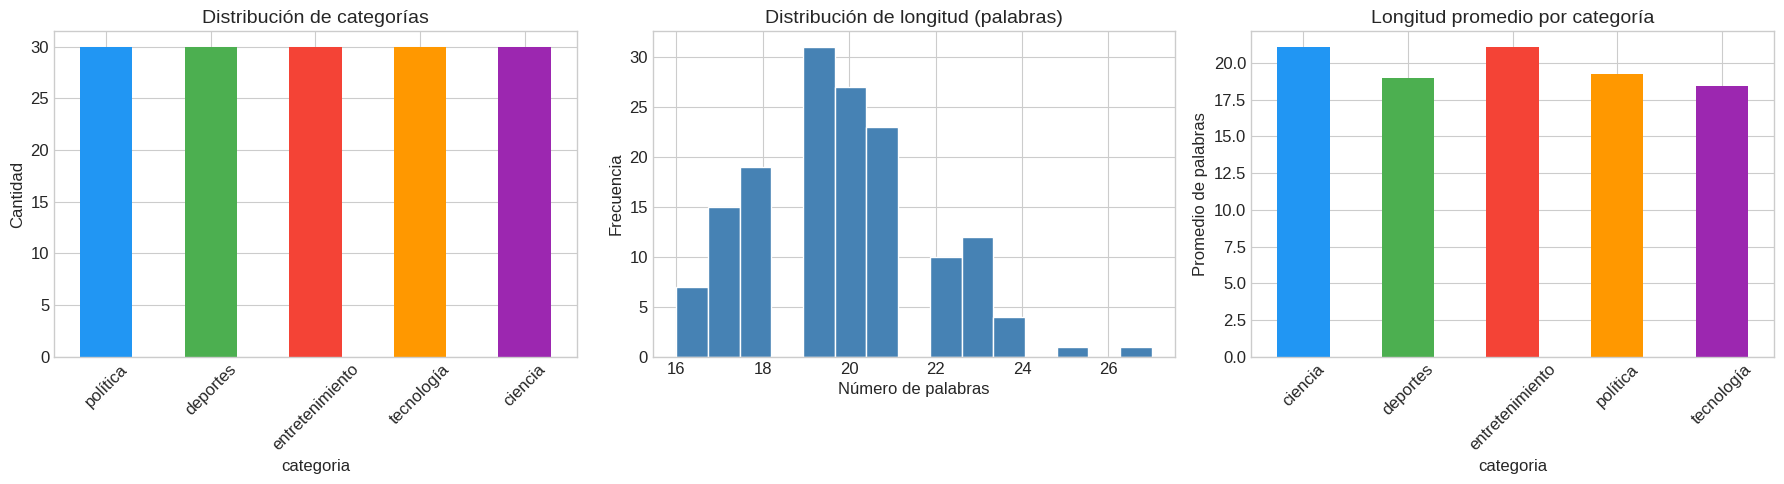

In [136]:
# Exploración del dataset

# Longitud de textos (en palabras)
df['num_palabras'] = df['texto'].apply(lambda x: len(x.split()))
df['num_caracteres'] = df['texto'].apply(len)

print("Estadísticas de longitud de textos:")
print(df[['num_palabras', 'num_caracteres']].describe().round(1))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de categorías
colores = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0']
df['categoria'].value_counts().plot(kind='bar', ax=axes[0], color=colores)
axes[0].set_title('Distribución de categorías', fontsize=14)
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Distribución de longitud de texto
df['num_palabras'].hist(bins=15, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de longitud (palabras)', fontsize=14)
axes[1].set_xlabel('Número de palabras')
axes[1].set_ylabel('Frecuencia')

# Longitud promedio por categoría
df.groupby('categoria')['num_palabras'].mean().plot(kind='bar', ax=axes[2], color=colores)
axes[2].set_title('Longitud promedio por categoría', fontsize=14)
axes[2].set_ylabel('Promedio de palabras')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [137]:
# Mostrar un ejemplo de cada categoría
print("=" * 80)
print("EJEMPLO DE CADA CATEGORÍA")
print("=" * 80)

for cat in df['categoria'].unique():
    ejemplo = df[df['categoria'] == cat].iloc[0]['texto']
    print(f"\n📌 [{cat.upper()}]:")
    print(f"   {ejemplo}")
    print("-" * 80)

EJEMPLO DE CADA CATEGORÍA

📌 [POLÍTICA]:
   El embajador colombiano ante la ONU presentó una propuesta para fortalecer la cooperación internacional en materia ambiental
--------------------------------------------------------------------------------

📌 [DEPORTES]:
   El golfista colombiano terminó en el tercer lugar del torneo internacional disputado en los campos de Augusta
--------------------------------------------------------------------------------

📌 [ENTRETENIMIENTO]:
   El muralista colombiano fue invitado a pintar un mural de quinientos metros cuadrados en uno de los edificios más emblemáticos de Berlín
--------------------------------------------------------------------------------

📌 [TECNOLOGÍA]:
   La empresa tecnológica presentó un procesador más rápido y eficiente que consume la mitad de energía que su predecesor
--------------------------------------------------------------------------------

📌 [CIENCIA]:
   Geólogos advirtieron sobre el aumento de la actividad sísmica

---

## 4. Experimentación guiada

### Experimento 1: Tokenización con NLTK

La tokenización es el **primer paso** en cualquier pipeline de PLN. Vamos a explorar cómo NLTK divide el texto en tokens (palabras y oraciones).

In [138]:
# Experimento 1: Tokenización de palabras y oraciones

# Texto de ejemplo con características interesantes para el español
texto_ejemplo = (
    "¡El equipo de Medellín ganó 3-0! El D.T. Carlos Pérez dijo: "
    '"Estamos muy contentos con el resultado". '
    "La Sra. López, presidenta del club, confirmó que el próximo partido "
    "será el 15/03/2026 a las 3:30 p.m. en el estadio Atanasio Girardot. "
    "¿Podrán mantener la racha de 10 victorias consecutivas?"
)

print("TEXTO ORIGINAL:")
print(texto_ejemplo)
print("\n" + "=" * 80)

TEXTO ORIGINAL:
¡El equipo de Medellín ganó 3-0! El D.T. Carlos Pérez dijo: "Estamos muy contentos con el resultado". La Sra. López, presidenta del club, confirmó que el próximo partido será el 15/03/2026 a las 3:30 p.m. en el estadio Atanasio Girardot. ¿Podrán mantener la racha de 10 victorias consecutivas?



In [139]:
# Tokenización de palabras
tokens_palabras = word_tokenize(texto_ejemplo, language='spanish')

print("TOKENIZACIÓN DE PALABRAS:")
print(f"Número de tokens: {len(tokens_palabras)}")
print(f"\nTokens: {tokens_palabras}")

print("\n" + "-" * 80)

# Tokenización de oraciones
tokens_oraciones = sent_tokenize(texto_ejemplo, language='spanish')

print("\nTOKENIZACIÓN DE ORACIONES:")
print(f"Número de oraciones: {len(tokens_oraciones)}")
for i, oracion in enumerate(tokens_oraciones):
    print(f"\n  Oración {i+1}: {oracion}")

TOKENIZACIÓN DE PALABRAS:
Número de tokens: 60

Tokens: ['¡El', 'equipo', 'de', 'Medellín', 'ganó', '3-0', '!', 'El', 'D.T', '.', 'Carlos', 'Pérez', 'dijo', ':', '``', 'Estamos', 'muy', 'contentos', 'con', 'el', 'resultado', "''", '.', 'La', 'Sra', '.', 'López', ',', 'presidenta', 'del', 'club', ',', 'confirmó', 'que', 'el', 'próximo', 'partido', 'será', 'el', '15/03/2026', 'a', 'las', '3:30', 'p.m', '.', 'en', 'el', 'estadio', 'Atanasio', 'Girardot', '.', '¿Podrán', 'mantener', 'la', 'racha', 'de', '10', 'victorias', 'consecutivas', '?']

--------------------------------------------------------------------------------

TOKENIZACIÓN DE ORACIONES:
Número de oraciones: 7

  Oración 1: ¡El equipo de Medellín ganó 3-0!

  Oración 2: El D.T.

  Oración 3: Carlos Pérez dijo: "Estamos muy contentos con el resultado".

  Oración 4: La Sra.

  Oración 5: López, presidenta del club, confirmó que el próximo partido será el 15/03/2026 a las 3:30 p.m.

  Oración 6: en el estadio Atanasio Girardot.


In [140]:
# Analizar diferentes tipos de tokens
print("ANÁLISIS DE TIPOS DE TOKENS:\n")

# Clasificar tokens
palabras = [t for t in tokens_palabras if t.isalpha()]
numeros = [t for t in tokens_palabras if t.isdigit()]
puntuacion = [t for t in tokens_palabras if not t.isalnum()]
otros = [t for t in tokens_palabras if not t.isalpha() and not t.isdigit() and t.isalnum()]

print(f"  Palabras ({len(palabras)}): {palabras[:10]}...")
print(f"  Números ({len(numeros)}): {numeros}")
print(f"  Puntuación ({len(puntuacion)}): {puntuacion}")
print(f"  Otros ({len(otros)}): {otros}")

ANÁLISIS DE TIPOS DE TOKENS:

  Palabras (40): ['equipo', 'de', 'Medellín', 'ganó', 'El', 'Carlos', 'Pérez', 'dijo', 'Estamos', 'muy']...
  Números (1): ['10']
  Puntuación (19): ['¡El', '3-0', '!', 'D.T', '.', ':', '``', "''", '.', '.', ',', ',', '15/03/2026', '3:30', 'p.m', '.', '.', '¿Podrán', '?']
  Otros (0): []


In [141]:
# Tokenizar algunas noticias del dataset
print("TOKENIZACIÓN DE NOTICIAS DEL DATASET:\n")

for i in range(3):
    texto = df.iloc[i]['texto']
    cat = df.iloc[i]['categoria']
    tokens = word_tokenize(texto, language='spanish')

    print(f"[{cat.upper()}] ({len(tokens)} tokens):")
    print(f"  Original: {texto[:80]}...")
    print(f"  Tokens:   {tokens[:10]}...")
    print()

TOKENIZACIÓN DE NOTICIAS DEL DATASET:

[POLÍTICA] (17 tokens):
  Original: El embajador colombiano ante la ONU presentó una propuesta para fortalecer la co...
  Tokens:   ['El', 'embajador', 'colombiano', 'ante', 'la', 'ONU', 'presentó', 'una', 'propuesta', 'para']...

[DEPORTES] (17 tokens):
  Original: El golfista colombiano terminó en el tercer lugar del torneo internacional dispu...
  Tokens:   ['El', 'golfista', 'colombiano', 'terminó', 'en', 'el', 'tercer', 'lugar', 'del', 'torneo']...

[ENTRETENIMIENTO] (22 tokens):
  Original: El muralista colombiano fue invitado a pintar un mural de quinientos metros cuad...
  Tokens:   ['El', 'muralista', 'colombiano', 'fue', 'invitado', 'a', 'pintar', 'un', 'mural', 'de']...



### Pregunta - Experimento 1

¿Qué problemas observaste al tokenizar texto en español? ¿Cómo se maneja la puntuación, las abreviaturas (D.T., Sra., p.m.) y los números (3-0, 15/03/2026, 3:30)? ¿En qué se diferencia la tokenización del español respecto a lo que esperarías en inglés?

*Escribe aquí tu respuesta...*

---

### Experimento 2: Stopwords y limpieza de texto

Ahora aprenderemos a **limpiar y normalizar** el texto eliminando elementos que no aportan significado relevante.

In [142]:
# Explorar las stopwords del español en NLTK
stop_words_es = set(stopwords.words('spanish'))

print(f"Número de stopwords en español (NLTK): {len(stop_words_es)}")
print(f"\nAlgunas stopwords:")

# Mostrar organizadas
lista_sw = sorted(list(stop_words_es))
for i in range(0, min(60, len(lista_sw)), 10):
    print(f"  {lista_sw[i:i+10]}")

Número de stopwords en español (NLTK): 313

Algunas stopwords:
  ['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra']
  ['cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ella']
  ['ellas', 'ellos', 'en', 'entre', 'era', 'erais', 'eran', 'eras', 'eres', 'es']
  ['esa', 'esas', 'ese', 'eso', 'esos', 'esta', 'estaba', 'estabais', 'estaban', 'estabas']
  ['estad', 'estada', 'estadas', 'estado', 'estados', 'estamos', 'estando', 'estar', 'estaremos', 'estará']
  ['estarán', 'estarás', 'estaré', 'estaréis', 'estaría', 'estaríais', 'estaríamos', 'estarían', 'estarías', 'estas']


In [143]:
# Función de limpieza completa de texto

def limpiar_texto(texto, quitar_stopwords=True, stopwords_set=None):
    """
    Pipeline de limpieza de texto:
    1. Convertir a minúsculas
    2. Remover caracteres especiales y puntuación
    3. Remover números
    4. Tokenizar
    5. Remover stopwords (opcional)
    6. Reconstruir texto limpio

    Args:
        texto: string con el texto original
        quitar_stopwords: si True, elimina stopwords
        stopwords_set: conjunto de stopwords a usar

    Returns:
        texto limpio como string
    """
    if stopwords_set is None:
        stopwords_set = set(stopwords.words('spanish'))

    # 1. Minúsculas
    texto = texto.lower()

    # 2. Remover puntuación y caracteres especiales
    texto = re.sub(r'[^a-záéíóúñü\s]', '', texto)

    # 3. Remover espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()

    # 4. Tokenizar
    tokens = texto.split()

    # 5. Remover stopwords
    if quitar_stopwords:
        tokens = [t for t in tokens if t not in stopwords_set]

    # 6. Reconstruir
    return ' '.join(tokens)


# Probar con un ejemplo
texto_prueba = df.iloc[0]['texto']
texto_limpio = limpiar_texto(texto_prueba)

print("ANTES de limpieza:")
print(f"  {texto_prueba}")
print(f"  ({len(texto_prueba.split())} palabras)")
print(f"\nDESPUÉS de limpieza:")
print(f"  {texto_limpio}")
print(f"  ({len(texto_limpio.split())} palabras)")

ANTES de limpieza:
  El embajador colombiano ante la ONU presentó una propuesta para fortalecer la cooperación internacional en materia ambiental
  (17 palabras)

DESPUÉS de limpieza:
  embajador colombiano onu presentó propuesta fortalecer cooperación internacional materia ambiental
  (10 palabras)


In [144]:
# Aplicar limpieza a todo el dataset
df['texto_limpio'] = df['texto'].apply(limpiar_texto)

# Mostrar 5 ejemplos de antes vs después
print("COMPARACIÓN ANTES vs DESPUÉS DE LIMPIEZA")
print("=" * 80)

for i in range(5):
    original = df.iloc[i]['texto']
    limpio = df.iloc[i]['texto_limpio']
    cat = df.iloc[i]['categoria']

    # Calcular reducción
    palabras_orig = len(original.split())
    palabras_limp = len(limpio.split())
    reduccion = (1 - palabras_limp / palabras_orig) * 100

    print(f"\n[{cat.upper()}]")
    print(f"  Original ({palabras_orig} palabras): {original[:80]}...")
    print(f"  Limpio   ({palabras_limp} palabras): {limpio[:80]}...")
    print(f"  Reducción: {reduccion:.1f}%")
    print("-" * 80)

COMPARACIÓN ANTES vs DESPUÉS DE LIMPIEZA

[POLÍTICA]
  Original (17 palabras): El embajador colombiano ante la ONU presentó una propuesta para fortalecer la co...
  Limpio   (10 palabras): embajador colombiano onu presentó propuesta fortalecer cooperación internacional...
  Reducción: 41.2%
--------------------------------------------------------------------------------

[DEPORTES]
  Original (17 palabras): El golfista colombiano terminó en el tercer lugar del torneo internacional dispu...
  Limpio   (10 palabras): golfista colombiano terminó tercer lugar torneo internacional disputado campos a...
  Reducción: 41.2%
--------------------------------------------------------------------------------

[ENTRETENIMIENTO]
  Original (22 palabras): El muralista colombiano fue invitado a pintar un mural de quinientos metros cuad...
  Limpio   (11 palabras): muralista colombiano invitado pintar mural quinientos metros cuadrados edificios...
  Reducción: 50.0%
-------------------------------------

ESTADÍSTICAS DE REDUCCIÓN POR STOPWORDS Y LIMPIEZA:

  Promedio de palabras originales: 19.8
  Promedio de palabras después de limpieza: 11.7
  Porcentaje promedio de reducción: 40.6%

  Por categoría:
    ciencia: 38.2% de palabras eliminadas
    deportes: 43.0% de palabras eliminadas
    entretenimiento: 43.0% de palabras eliminadas
    política: 42.8% de palabras eliminadas
    tecnología: 36.1% de palabras eliminadas


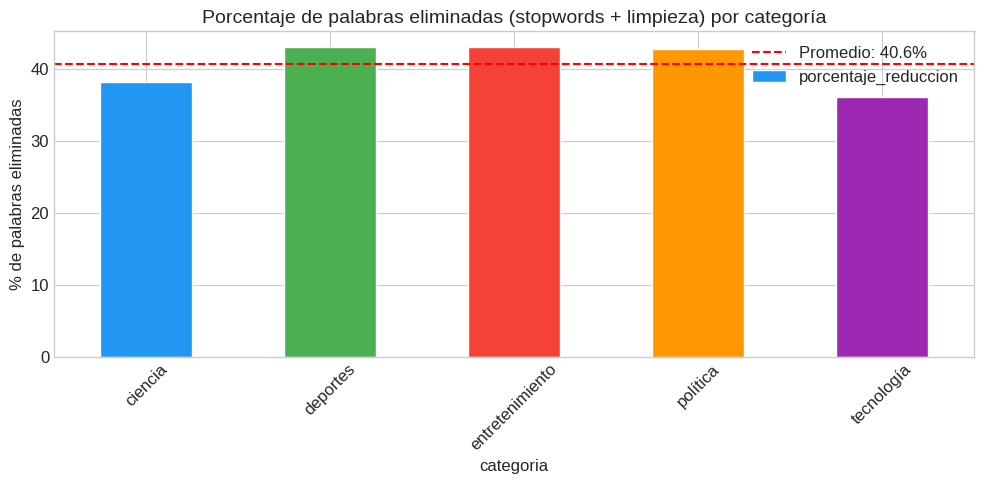

In [145]:
# Análisis estadístico de la limpieza
df['palabras_original'] = df['texto'].apply(lambda x: len(x.split()))
df['palabras_limpio'] = df['texto_limpio'].apply(lambda x: len(x.split()))
df['porcentaje_reduccion'] = (1 - df['palabras_limpio'] / df['palabras_original']) * 100

print("ESTADÍSTICAS DE REDUCCIÓN POR STOPWORDS Y LIMPIEZA:")
print(f"\n  Promedio de palabras originales: {df['palabras_original'].mean():.1f}")
print(f"  Promedio de palabras después de limpieza: {df['palabras_limpio'].mean():.1f}")
print(f"  Porcentaje promedio de reducción: {df['porcentaje_reduccion'].mean():.1f}%")

print("\n  Por categoría:")
resumen = df.groupby('categoria')['porcentaje_reduccion'].mean().round(1)
for cat, pct in resumen.items():
    print(f"    {cat}: {pct}% de palabras eliminadas")

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby('categoria')['porcentaje_reduccion'].mean().plot(
    kind='bar', color=colores, edgecolor='white', ax=ax
)
ax.set_title('Porcentaje de palabras eliminadas (stopwords + limpieza) por categoría', fontsize=14)
ax.set_ylabel('% de palabras eliminadas')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=df['porcentaje_reduccion'].mean(), color='red', linestyle='--', label=f'Promedio: {df["porcentaje_reduccion"].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

### Pregunta - Experimento 2

¿Qué porcentaje de palabras se eliminaron como stopwords? ¿Crees que se perdió información importante al eliminar las stopwords? ¿En qué casos podría ser problemático eliminarlas? Da un ejemplo concreto.

*Escribe aquí tu respuesta...*

---

### Experimento 3: Stemming vs Lematización

Comparemos las dos técnicas de normalización de palabras: **stemming** (cortar sufijos) vs **lematización** (encontrar la forma base del diccionario).

In [146]:
# Crear el stemmer para español
stemmer_es = SnowballStemmer('spanish')

# Lista de palabras para comparar
palabras_prueba = [
    'corriendo', 'corredor', 'corredores', 'correr', 'corrió',
    'jugando', 'jugador', 'jugadores', 'jugar', 'jugaron',
    'investigación', 'investigadores', 'investigar', 'investigando',
    'gobierno', 'gobernador', 'gobernar', 'gobernante',
    'tecnológico', 'tecnología', 'tecnologías',
    'universidad', 'universitario', 'universitarios',
    'colombiano', 'colombiana', 'colombianos',
    'mejor', 'mejores', 'mejorando', 'mejorar',
    'rápido', 'rápidamente', 'rapidez',
    'feliz', 'felicidad', 'felizmente'
]

# Aplicar stemming
stems = [stemmer_es.stem(p) for p in palabras_prueba]

# Crear tabla comparativa
tabla_stem = pd.DataFrame({
    'Palabra original': palabras_prueba,
    'Stem (Snowball)': stems
})

print("STEMMING CON SNOWBALL STEMMER (ESPAÑOL)")
print("=" * 50)
print(tabla_stem.to_string(index=False))

STEMMING CON SNOWBALL STEMMER (ESPAÑOL)
Palabra original Stem (Snowball)
       corriendo            corr
        corredor        corredor
      corredores        corredor
          correr            corr
          corrió            corr
         jugando             jug
         jugador         jugador
       jugadores         jugador
           jugar             jug
         jugaron             jug
   investigación        investig
  investigadores        investig
      investigar        investig
    investigando        investig
        gobierno         gobiern
      gobernador          gobern
        gobernar          gobern
      gobernante          gobern
     tecnológico        tecnolog
      tecnología        tecnolog
     tecnologías        tecnolog
     universidad         univers
   universitario    universitari
  universitarios    universitari
      colombiano       colombian
      colombiana       colombian
     colombianos       colombian
           mejor           mejor
   

In [147]:
# Lematización con WordNet (limitada para español, pero ilustrativa)
lemmatizer = WordNetLemmatizer()

# WordNet funciona mejor con inglés, pero probamos para comparación
# Para español usaremos un enfoque basado en reglas simples

def lematizar_simple_es(palabra):
    """
    Lematización simple para español basada en reglas.
    NOTA: Para producción se recomienda usar SpaCy con modelo en español.
    Esta función es educativa para entender el concepto.
    """
    # Reglas simples de lematización para español
    reglas = [
        # Participios y gerundios
        (r'ando$', 'ar'), (r'endo$', 'er'), (r'iendo$', 'ir'),
        # Plurales
        (r'es$', ''), (r's$', ''),
        # Diminutivos / aumentativos
        (r'mente$', ''),
    ]

    # Diccionario de lemas conocidos (para demostración)
    lemas_dict = {
        'corriendo': 'correr', 'corredor': 'corredor', 'corredores': 'corredor',
        'correr': 'correr', 'corrió': 'correr',
        'jugando': 'jugar', 'jugador': 'jugador', 'jugadores': 'jugador',
        'jugar': 'jugar', 'jugaron': 'jugar',
        'investigación': 'investigación', 'investigadores': 'investigador',
        'investigar': 'investigar', 'investigando': 'investigar',
        'gobierno': 'gobierno', 'gobernador': 'gobernador',
        'gobernar': 'gobernar', 'gobernante': 'gobernante',
        'tecnológico': 'tecnología', 'tecnología': 'tecnología',
        'tecnologías': 'tecnología',
        'universidad': 'universidad', 'universitario': 'universidad',
        'universitarios': 'universidad',
        'colombiano': 'colombiano', 'colombiana': 'colombiano',
        'colombianos': 'colombiano',
        'mejor': 'bueno', 'mejores': 'bueno',
        'mejorando': 'mejorar', 'mejorar': 'mejorar',
        'rápido': 'rápido', 'rápidamente': 'rápido', 'rapidez': 'rápido',
        'feliz': 'feliz', 'felicidad': 'feliz', 'felizmente': 'feliz'
    }

    return lemas_dict.get(palabra, palabra)


# Aplicar lematización
lemas = [lematizar_simple_es(p) for p in palabras_prueba]

# Tabla comparativa completa
tabla_completa = pd.DataFrame({
    'Palabra': palabras_prueba,
    'Stem': stems,
    'Lema': lemas
})

print("COMPARACIÓN: STEMMING vs LEMATIZACIÓN")
print("=" * 65)
print(tabla_completa.to_string(index=False))
print("\n" + "=" * 65)
print("\nNota: El stem puede NO ser una palabra real (ej: 'corr', 'jug')")
print("El lema SIEMPRE es una palabra real del diccionario.")

COMPARACIÓN: STEMMING vs LEMATIZACIÓN
       Palabra         Stem          Lema
     corriendo         corr        correr
      corredor     corredor      corredor
    corredores     corredor      corredor
        correr         corr        correr
        corrió         corr        correr
       jugando          jug         jugar
       jugador      jugador       jugador
     jugadores      jugador       jugador
         jugar          jug         jugar
       jugaron          jug         jugar
 investigación     investig investigación
investigadores     investig  investigador
    investigar     investig    investigar
  investigando     investig    investigar
      gobierno      gobiern      gobierno
    gobernador       gobern    gobernador
      gobernar       gobern      gobernar
    gobernante       gobern    gobernante
   tecnológico     tecnolog    tecnología
    tecnología     tecnolog    tecnología
   tecnologías     tecnolog    tecnología
   universidad      univers   universi

In [148]:
# Visualizar los problemas del stemming

# Encontrar casos problemáticos
print("CASOS DONDE EL STEMMING ES PROBLEMÁTICO:\n")

problematicos = [
    ('corriendo', 'corredor'),
    ('gobierno', 'gobernar'),
    ('universidad', 'universitario'),
    ('investigación', 'investigar'),
]

for p1, p2 in problematicos:
    s1 = stemmer_es.stem(p1)
    s2 = stemmer_es.stem(p2)
    misma_raiz = "Sí" if s1 == s2 else "No"
    print(f"  '{p1}' → stem: '{s1}'")
    print(f"  '{p2}' → stem: '{s2}'")
    print(f"  ¿Misma raíz? {misma_raiz}")
    if s1 != s2:
        print(f"  ⚠️ Problema: palabras relacionadas tienen stems diferentes")
    print()

print("\n" + "-" * 60)
print("\nCASOS DONDE EL STEMMING ES DEMASIADO AGRESIVO:\n")

agresivos = [
    ('universidad', 'universo'),
    ('colombiano', 'colombina'),
]

for p1, p2 in agresivos:
    s1 = stemmer_es.stem(p1)
    s2 = stemmer_es.stem(p2)
    print(f"  '{p1}' → stem: '{s1}'")
    print(f"  '{p2}' → stem: '{s2}'")
    if s1 == s2:
        print(f"  ⚠️ Problema: palabras con significado diferente tienen el mismo stem")
    print()

CASOS DONDE EL STEMMING ES PROBLEMÁTICO:

  'corriendo' → stem: 'corr'
  'corredor' → stem: 'corredor'
  ¿Misma raíz? No
  ⚠️ Problema: palabras relacionadas tienen stems diferentes

  'gobierno' → stem: 'gobiern'
  'gobernar' → stem: 'gobern'
  ¿Misma raíz? No
  ⚠️ Problema: palabras relacionadas tienen stems diferentes

  'universidad' → stem: 'univers'
  'universitario' → stem: 'universitari'
  ¿Misma raíz? No
  ⚠️ Problema: palabras relacionadas tienen stems diferentes

  'investigación' → stem: 'investig'
  'investigar' → stem: 'investig'
  ¿Misma raíz? Sí


------------------------------------------------------------

CASOS DONDE EL STEMMING ES DEMASIADO AGRESIVO:

  'universidad' → stem: 'univers'
  'universo' → stem: 'univers'
  ⚠️ Problema: palabras con significado diferente tienen el mismo stem

  'colombiano' → stem: 'colombian'
  'colombina' → stem: 'colombin'



In [149]:
# Aplicar stemming al dataset
def aplicar_stemming(texto, stemmer):
    """Aplica stemming a cada palabra del texto."""
    tokens = texto.split()
    stems = [stemmer.stem(t) for t in tokens]
    return ' '.join(stems)

# Aplicar al dataset limpio
df['texto_stem'] = df['texto_limpio'].apply(lambda x: aplicar_stemming(x, stemmer_es))

# Mostrar comparación
print("COMPARACIÓN: TEXTO LIMPIO vs STEMMED")
print("=" * 80)

for i in range(3):
    print(f"\n[{df.iloc[i]['categoria'].upper()}]")
    print(f"  Limpio:  {df.iloc[i]['texto_limpio'][:80]}...")
    print(f"  Stemmed: {df.iloc[i]['texto_stem'][:80]}...")
    print("-" * 80)

COMPARACIÓN: TEXTO LIMPIO vs STEMMED

[POLÍTICA]
  Limpio:  embajador colombiano onu presentó propuesta fortalecer cooperación internacional...
  Stemmed: embaj colombian onu present propuest fortalec cooper internacional materi ambien...
--------------------------------------------------------------------------------

[DEPORTES]
  Limpio:  golfista colombiano terminó tercer lugar torneo internacional disputado campos a...
  Stemmed: golfist colombian termin terc lug torne internacional disput camp august...
--------------------------------------------------------------------------------

[ENTRETENIMIENTO]
  Limpio:  muralista colombiano invitado pintar mural quinientos metros cuadrados edificios...
  Stemmed: mural colombian invit pint mural quinient metr cuadr edifici emblemat berlin...
--------------------------------------------------------------------------------


### Pregunta - Experimento 3

¿En qué casos el stemming produjo resultados incorrectos o confusos? ¿Cuándo preferirías lematización sobre stemming? ¿Hay algún caso donde el stemming sea preferible? Explica con ejemplos concretos de la tabla anterior.

*Escribe aquí tu respuesta...*

---

### Experimento 4: Bag of Words (BoW)

Ahora vamos a convertir nuestros textos en **vectores numéricos** usando la representación Bag of Words.

In [150]:
# Crear la representación Bag of Words con CountVectorizer

# Usar los textos limpios
vectorizer_bow = CountVectorizer(
    max_features=500,   # Limitar a las 500 palabras más frecuentes
    min_df=2,           # La palabra debe aparecer en al menos 2 documentos
    max_df=0.95         # Ignorar palabras que aparecen en más del 95% de documentos
)

# Ajustar y transformar
matriz_bow = vectorizer_bow.fit_transform(df['texto_limpio'])

print(f"Forma de la matriz BoW: {matriz_bow.shape}")
print(f"  - {matriz_bow.shape[0]} documentos (noticias)")
print(f"  - {matriz_bow.shape[1]} características (palabras únicas)")
print(f"\nTamaño del vocabulario: {len(vectorizer_bow.vocabulary_)} palabras")
print(f"\nAlgunas palabras del vocabulario:")
vocabulario = vectorizer_bow.get_feature_names_out()
print(f"  Primeras 20: {list(vocabulario[:20])}")
print(f"  Últimas 20:  {list(vocabulario[-20:])}")

Forma de la matriz BoW: (150, 266)
  - 150 documentos (noticias)
  - 266 características (palabras únicas)

Tamaño del vocabulario: 266 palabras

Algunas palabras del vocabulario:
  Primeras 20: ['acuerdo', 'afecta', 'agua', 'algoritmo', 'anunció', 'aplicación', 'aprendizaje', 'aprobó', 'artificial', 'artista', 'aumento', 'autónomo', 'año', 'años', 'basada', 'biólogos', 'bogotá', 'cada', 'calles', 'cambios']
  Últimas 20:  ['transparencia', 'tras', 'tratamiento', 'tres', 'técnico', 'título', 'universidad', 'usuario', 'usuarios', 'vacuna', 'vehículo', 'veinte', 'victoria', 'virtual', 'visitantes', 'voto', 'zona', 'zonas', 'álbum', 'último']


In [151]:
# Visualizar la matriz BoW para las primeras 5 noticias

# Seleccionar primeras 5 noticias y primeras 20 palabras
df_bow_muestra = pd.DataFrame(
    matriz_bow[:5, :20].toarray(),
    columns=vocabulario[:20],
    index=[f"Noticia {i} ({df.iloc[i]['categoria']})" for i in range(5)]
)

print("MATRIZ BAG OF WORDS (primeras 5 noticias, primeras 20 palabras):")
print("=" * 80)
print(df_bow_muestra.to_string())
print("\n(La mayoría de valores son 0 porque cada noticia usa un subconjunto")
print(" pequeño del vocabulario total → matriz dispersa o 'sparse')")

MATRIZ BAG OF WORDS (primeras 5 noticias, primeras 20 palabras):
                             acuerdo  afecta  agua  algoritmo  anunció  aplicación  aprendizaje  aprobó  artificial  artista  aumento  autónomo  año  años  basada  biólogos  bogotá  cada  calles  cambios
Noticia 0 (política)               0       0     0          0        0           0            0       0           0        0        0         0    0     0       0         0       0     0       0        0
Noticia 1 (deportes)               0       0     0          0        0           0            0       0           0        0        0         0    0     0       0         0       0     0       0        0
Noticia 2 (entretenimiento)        0       0     0          0        0           0            0       0           0        0        0         0    0     0       0         0       0     0       0        0
Noticia 3 (política)               0       0     0          0        0           0            0       0           0    

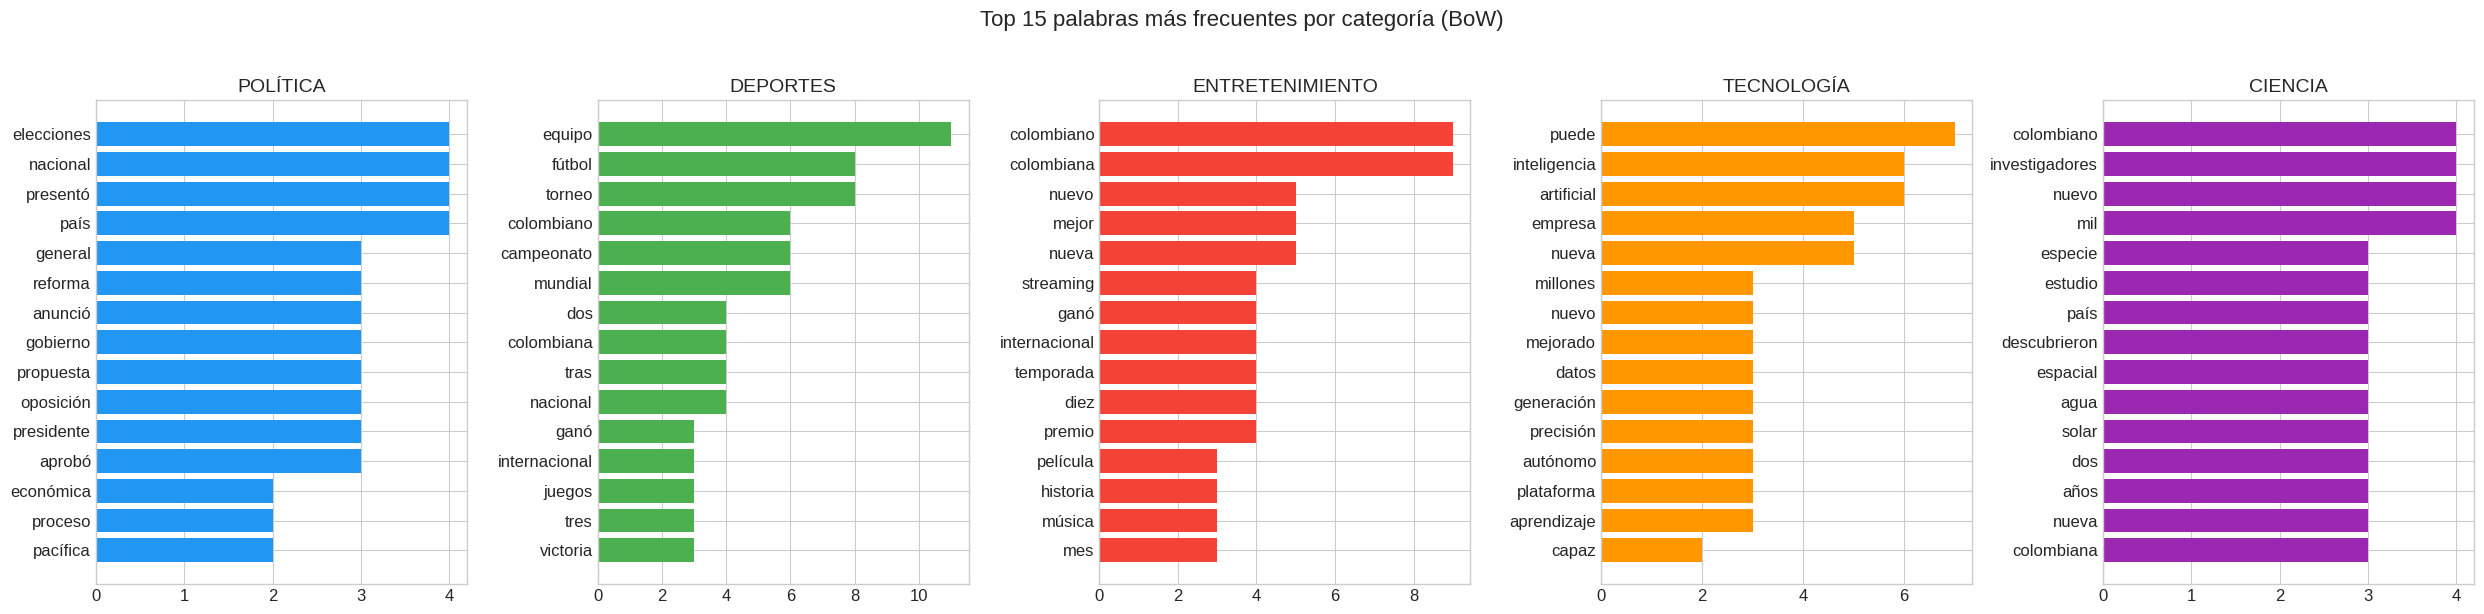

In [152]:
# Palabras más frecuentes por categoría

def top_palabras_por_categoria(df, vectorizer, matriz, n_top=15):
    """Obtiene las N palabras más frecuentes por cada categoría."""
    vocab = vectorizer.get_feature_names_out()
    resultados = {}

    for cat in df['categoria'].unique():
        # Índices de documentos de esta categoría
        indices = df[df['categoria'] == cat].index.tolist()
        # Sumar frecuencias de todas las noticias de la categoría
        frecuencias = np.array(matriz[indices].sum(axis=0)).flatten()
        # Obtener las top N
        top_indices = frecuencias.argsort()[-n_top:][::-1]
        resultados[cat] = [(vocab[i], frecuencias[i]) for i in top_indices]

    return resultados

top_palabras = top_palabras_por_categoria(df, vectorizer_bow, matriz_bow, n_top=15)

# Visualizar
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for idx, (cat, palabras) in enumerate(top_palabras.items()):
    words = [p[0] for p in palabras]
    counts = [p[1] for p in palabras]

    axes[idx].barh(range(len(words)), counts, color=colores[idx])
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].set_title(cat.upper(), fontsize=14)
    axes[idx].invert_yaxis()

plt.suptitle('Top 15 palabras más frecuentes por categoría (BoW)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

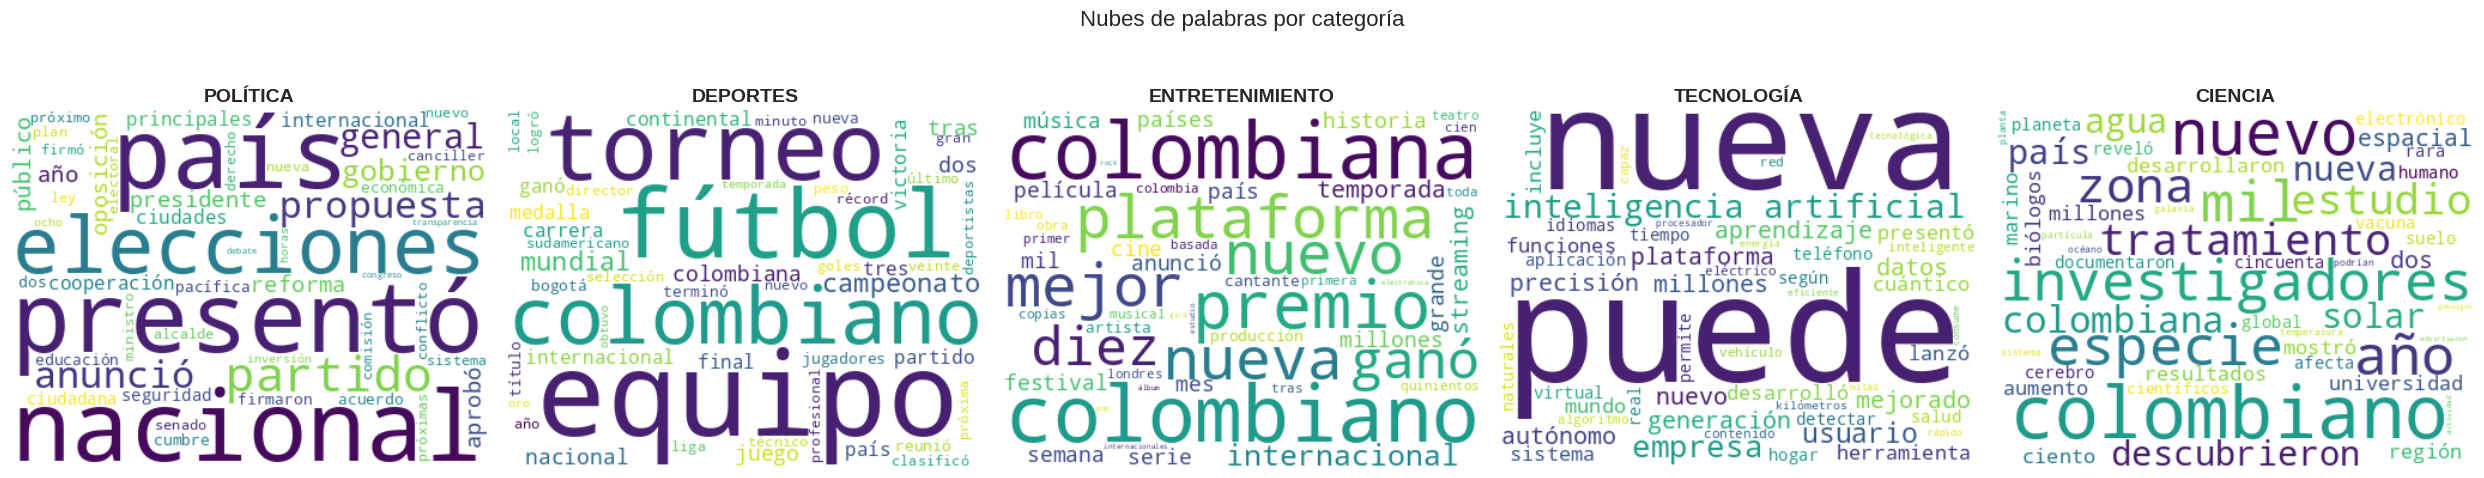

In [153]:
# Nubes de palabras por categoría

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for idx, cat in enumerate(df['categoria'].unique()):
    # Unir todos los textos limpios de la categoría
    texto_cat = ' '.join(df[df['categoria'] == cat]['texto_limpio'].tolist())

    # Generar nube de palabras
    wordcloud = WordCloud(
        width=400, height=300,
        background_color='white',
        colormap='viridis',
        max_words=50,
        random_state=42
    ).generate(texto_cat)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(cat.upper(), fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Nubes de palabras por categoría', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Pregunta - Experimento 4

¿Qué palabras son más características de cada categoría según el BoW y las nubes de palabras? ¿La representación BoW captura bien el significado del texto o tiene limitaciones? Identifica al menos una palabra que aparece en varias categorías y explica por qué eso podría ser un problema.

*Escribe aquí tu respuesta...*

---

### Experimento 5: TF-IDF (Term Frequency - Inverse Document Frequency)

TF-IDF mejora la representación BoW al **ponderar las palabras** según su importancia relativa. Las palabras que aparecen en muchos documentos reciben menor peso, mientras que las palabras específicas de pocos documentos reciben mayor peso.

Recordemos las fórmulas:

$$TF(t, d) = \frac{\text{frecuencia de } t \text{ en } d}{\text{total de términos en } d}$$

$$IDF(t) = \log\left(\frac{N}{1 + df(t)}\right)$$

$$\text{TF-IDF}(t, d) = TF(t, d) \times IDF(t)$$

In [154]:
# Crear la representación TF-IDF

vectorizer_tfidf = TfidfVectorizer(
    max_features=500,   # Mismo número de características que BoW
    min_df=2,
    max_df=0.95
)

# Ajustar y transformar
matriz_tfidf = vectorizer_tfidf.fit_transform(df['texto_limpio'])

print(f"Forma de la matriz TF-IDF: {matriz_tfidf.shape}")
print(f"  - {matriz_tfidf.shape[0]} documentos")
print(f"  - {matriz_tfidf.shape[1]} características")

# Comparar con BoW para una noticia
print("\n" + "=" * 80)
print("COMPARACIÓN BoW vs TF-IDF para la primera noticia:")
print(f"\nNoticia: {df.iloc[0]['texto'][:80]}...")
print(f"Categoría: {df.iloc[0]['categoria']}")

Forma de la matriz TF-IDF: (150, 266)
  - 150 documentos
  - 266 características

COMPARACIÓN BoW vs TF-IDF para la primera noticia:

Noticia: El embajador colombiano ante la ONU presentó una propuesta para fortalecer la co...
Categoría: política


In [155]:
# Comparar valores BoW vs TF-IDF para la primera noticia

# Obtener vectores de la primera noticia
bow_vec = matriz_bow[0].toarray().flatten()
tfidf_vec = matriz_tfidf[0].toarray().flatten()

# Encontrar palabras con valores no-cero en esta noticia
vocab_bow = vectorizer_bow.get_feature_names_out()
vocab_tfidf = vectorizer_tfidf.get_feature_names_out()

# Palabras presentes en la primera noticia (BoW)
indices_no_cero = np.where(bow_vec > 0)[0]

# Crear tabla comparativa
comparacion = []
for idx in indices_no_cero:
    palabra = vocab_bow[idx]
    # Buscar la misma palabra en TF-IDF
    if palabra in vocab_tfidf:
        idx_tfidf = np.where(vocab_tfidf == palabra)[0]
        if len(idx_tfidf) > 0:
            tfidf_val = tfidf_vec[idx_tfidf[0]]
        else:
            tfidf_val = 0.0
    else:
        tfidf_val = 0.0

    comparacion.append({
        'Palabra': palabra,
        'BoW (frecuencia)': int(bow_vec[idx]),
        'TF-IDF (peso)': round(tfidf_val, 4)
    })

df_comp = pd.DataFrame(comparacion).sort_values('TF-IDF (peso)', ascending=False)

print("COMPARACIÓN BoW vs TF-IDF (misma noticia):")
print("=" * 55)
print(df_comp.to_string(index=False))
print("\n→ Observa cómo TF-IDF asigna diferentes pesos a palabras")
print("  que tienen la misma frecuencia (BoW=1). Las palabras más")
print("  específicas reciben mayor peso TF-IDF.")

COMPARACIÓN BoW vs TF-IDF (misma noticia):
      Palabra  BoW (frecuencia)  TF-IDF (peso)
  cooperación                 1         0.5396
    propuesta                 1         0.5081
     presentó                 1         0.4320
internacional                 1         0.3971
   colombiano                 1         0.3261

→ Observa cómo TF-IDF asigna diferentes pesos a palabras
  que tienen la misma frecuencia (BoW=1). Las palabras más
  específicas reciben mayor peso TF-IDF.


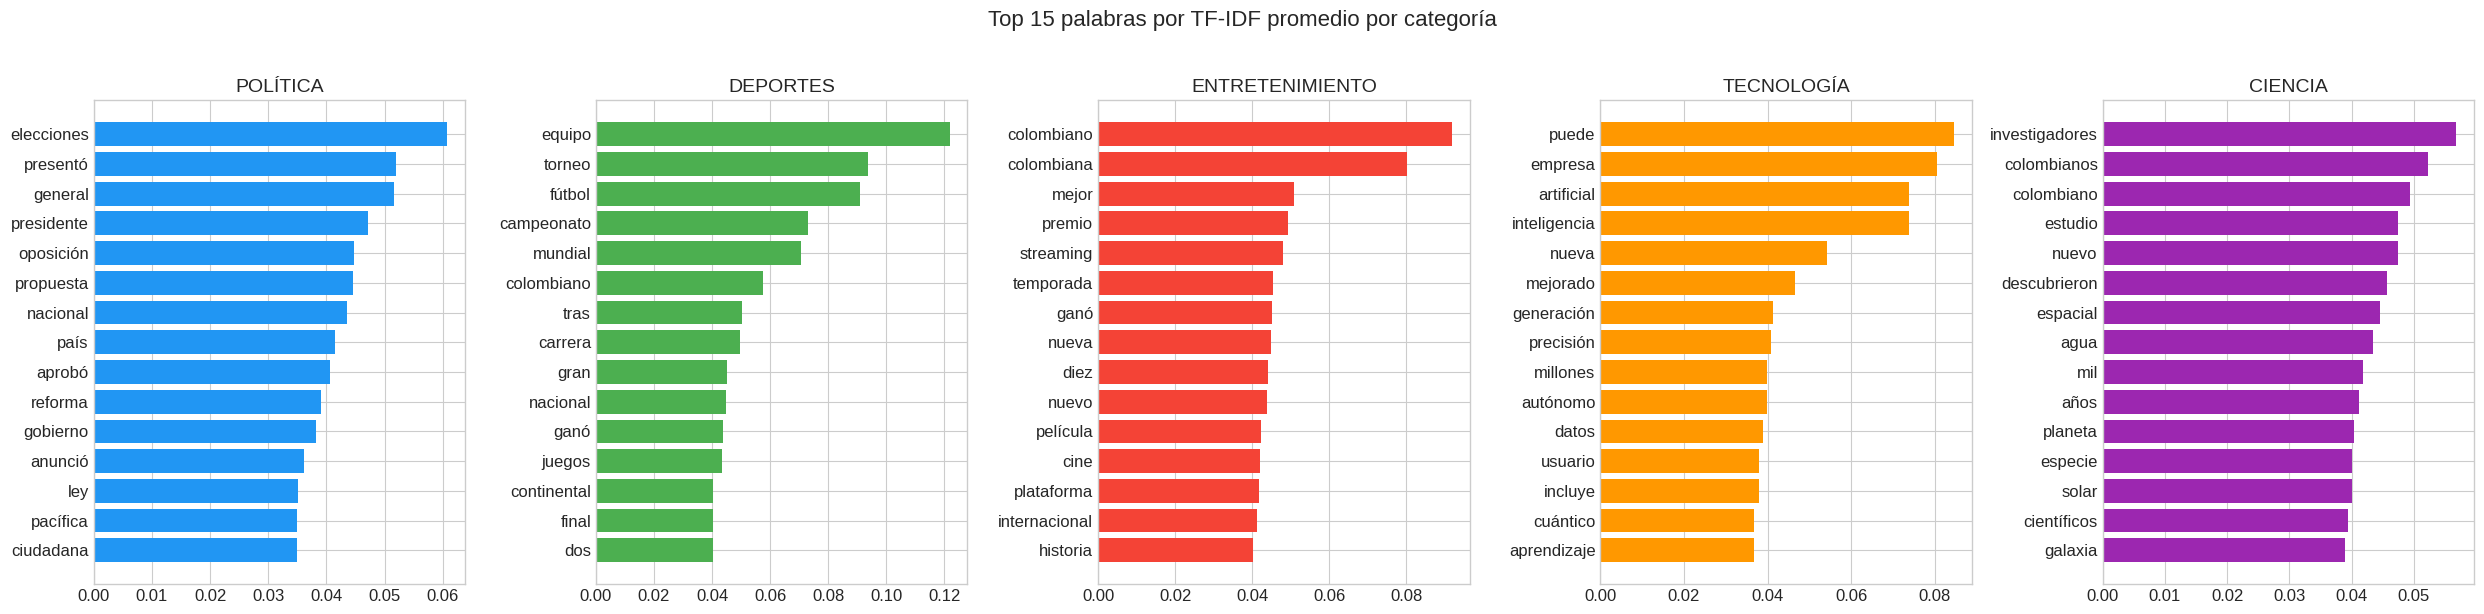

In [156]:
# Top palabras por TF-IDF por categoría

def top_tfidf_por_categoria(df, vectorizer, matriz, n_top=15):
    """Obtiene las N palabras con mayor TF-IDF promedio por categoría."""
    vocab = vectorizer.get_feature_names_out()
    resultados = {}

    for cat in df['categoria'].unique():
        indices = df[df['categoria'] == cat].index.tolist()
        # Promedio de TF-IDF para esta categoría
        tfidf_promedio = np.array(matriz[indices].mean(axis=0)).flatten()
        top_indices = tfidf_promedio.argsort()[-n_top:][::-1]
        resultados[cat] = [(vocab[i], round(tfidf_promedio[i], 4)) for i in top_indices]

    return resultados

top_tfidf = top_tfidf_por_categoria(df, vectorizer_tfidf, matriz_tfidf, n_top=15)

# Visualizar
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for idx, (cat, palabras) in enumerate(top_tfidf.items()):
    words = [p[0] for p in palabras]
    scores = [p[1] for p in palabras]

    axes[idx].barh(range(len(words)), scores, color=colores[idx])
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].set_title(cat.upper(), fontsize=14)
    axes[idx].invert_yaxis()

plt.suptitle('Top 15 palabras por TF-IDF promedio por categoría', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [157]:
# Comparar directamente BoW vs TF-IDF para una categoría

cat_ejemplo = 'deportes'

# Top 10 por BoW
bow_top = top_palabras[cat_ejemplo][:10]
# Top 10 por TF-IDF
tfidf_top = top_tfidf[cat_ejemplo][:10]

print(f"COMPARACIÓN BoW vs TF-IDF para '{cat_ejemplo.upper()}'")
print("=" * 60)
print(f"{'Rank':<6} {'BoW (frecuencia)':<25} {'TF-IDF (peso)':<25}")
print("-" * 60)

for i in range(10):
    bow_w, bow_c = bow_top[i]
    tfidf_w, tfidf_s = tfidf_top[i]
    print(f"{i+1:<6} {bow_w:<18} ({bow_c:<4})  {tfidf_w:<18} ({tfidf_s:.4f})")

print("\n→ Nota cómo las palabras más importantes cambian entre BoW y TF-IDF.")
print("  TF-IDF destaca palabras más específicas de la categoría.")

COMPARACIÓN BoW vs TF-IDF para 'DEPORTES'
Rank   BoW (frecuencia)          TF-IDF (peso)            
------------------------------------------------------------
1      equipo             (11  )  equipo             (0.1219)
2      fútbol             (8   )  torneo             (0.0937)
3      torneo             (8   )  fútbol             (0.0909)
4      colombiano         (6   )  campeonato         (0.0730)
5      campeonato         (6   )  mundial            (0.0705)
6      mundial            (6   )  colombiano         (0.0576)
7      dos                (4   )  tras               (0.0503)
8      colombiana         (4   )  carrera            (0.0497)
9      tras               (4   )  gran               (0.0453)
10     nacional           (4   )  nacional           (0.0449)

→ Nota cómo las palabras más importantes cambian entre BoW y TF-IDF.
  TF-IDF destaca palabras más específicas de la categoría.


### Pregunta - Experimento 5

¿Qué diferencias observas entre las palabras más importantes según BoW vs TF-IDF? ¿Qué palabras tienen TF-IDF alto y por qué? ¿Qué palabras tienen TF-IDF bajo a pesar de ser frecuentes? Explica con ejemplos del dataset.

*Escribe aquí tu respuesta...*

---

### Experimento 6: N-gramas

Los n-gramas nos permiten capturar **secuencias de palabras** que aparecen juntas, añadiendo contexto local que los unigramas (palabras individuales) no pueden capturar.

In [158]:
# Generar bigramas y trigramas de ejemplo

texto_ejemplo_ng = "la inteligencia artificial cambió el mundo de la tecnología moderna"
tokens_ng = texto_ejemplo_ng.split()

# Generar n-gramas
unigramas = list(ngrams(tokens_ng, 1))
bigramas = list(ngrams(tokens_ng, 2))
trigramas = list(ngrams(tokens_ng, 3))

print(f"Texto: '{texto_ejemplo_ng}'")
print("\nUNIGRAMAS (n=1):")
for u in unigramas:
    print(f"  {u[0]}")

print("\nBIGRAMAS (n=2):")
for b in bigramas:
    print(f"  '{b[0]} {b[1]}'")

print("\nTRIGRAMAS (n=3):")
for t in trigramas:
    print(f"  '{t[0]} {t[1]} {t[2]}'")

Texto: 'la inteligencia artificial cambió el mundo de la tecnología moderna'

UNIGRAMAS (n=1):
  la
  inteligencia
  artificial
  cambió
  el
  mundo
  de
  la
  tecnología
  moderna

BIGRAMAS (n=2):
  'la inteligencia'
  'inteligencia artificial'
  'artificial cambió'
  'cambió el'
  'el mundo'
  'mundo de'
  'de la'
  'la tecnología'
  'tecnología moderna'

TRIGRAMAS (n=3):
  'la inteligencia artificial'
  'inteligencia artificial cambió'
  'artificial cambió el'
  'cambió el mundo'
  'el mundo de'
  'mundo de la'
  'de la tecnología'
  'la tecnología moderna'


In [159]:
# Bigramas más frecuentes en todo el dataset

def obtener_top_ngramas(textos, n=2, top_k=20):
    """Obtiene los n-gramas más frecuentes de una lista de textos."""
    todos_ngramas = []
    for texto in textos:
        tokens = texto.split()
        todos_ngramas.extend(list(ngrams(tokens, n)))

    # Convertir a strings para contar
    ngramas_str = [' '.join(ng) for ng in todos_ngramas]
    contador = Counter(ngramas_str)
    return contador.most_common(top_k)


# Top bigramas por categoría
print("TOP 10 BIGRAMAS MÁS FRECUENTES POR CATEGORÍA")
print("=" * 60)

for cat in df['categoria'].unique():
    textos_cat = df[df['categoria'] == cat]['texto_limpio'].tolist()
    top_bg = obtener_top_ngramas(textos_cat, n=2, top_k=10)

    print(f"\n{cat.upper()}:")
    for bigrama, freq in top_bg:
        print(f"  '{bigrama}' → {freq} veces")

TOP 10 BIGRAMAS MÁS FRECUENTES POR CATEGORÍA

POLÍTICA:
  'principales ciudades' → 2 veces
  'gobierno nacional' → 2 veces
  'próximas elecciones' → 2 veces
  'próximo año' → 2 veces
  'ocho horas' → 2 veces
  'congreso aprobó' → 2 veces
  'embajador colombiano' → 1 veces
  'colombiano onu' → 1 veces
  'onu presentó' → 1 veces
  'presentó propuesta' → 1 veces

DEPORTES:
  'torneo internacional' → 3 veces
  'equipo fútbol' → 2 veces
  'director técnico' → 2 veces
  'próxima temporada' → 2 veces
  'golfista colombiano' → 1 veces
  'colombiano terminó' → 1 veces
  'terminó tercer' → 1 veces
  'tercer lugar' → 1 veces
  'lugar torneo' → 1 veces
  'internacional disputado' → 1 veces

ENTRETENIMIENTO:
  'ganó premio' → 3 veces
  'cien mil' → 2 veces
  'copias primera' → 2 veces
  'primera semana' → 2 veces
  'próximo mes' → 2 veces
  'nueva temporada' → 2 veces
  'plataformas streaming' → 2 veces
  'plataforma streaming' → 2 veces
  'mil visitantes' → 2 veces
  'colombiana ganó' → 2 veces

T

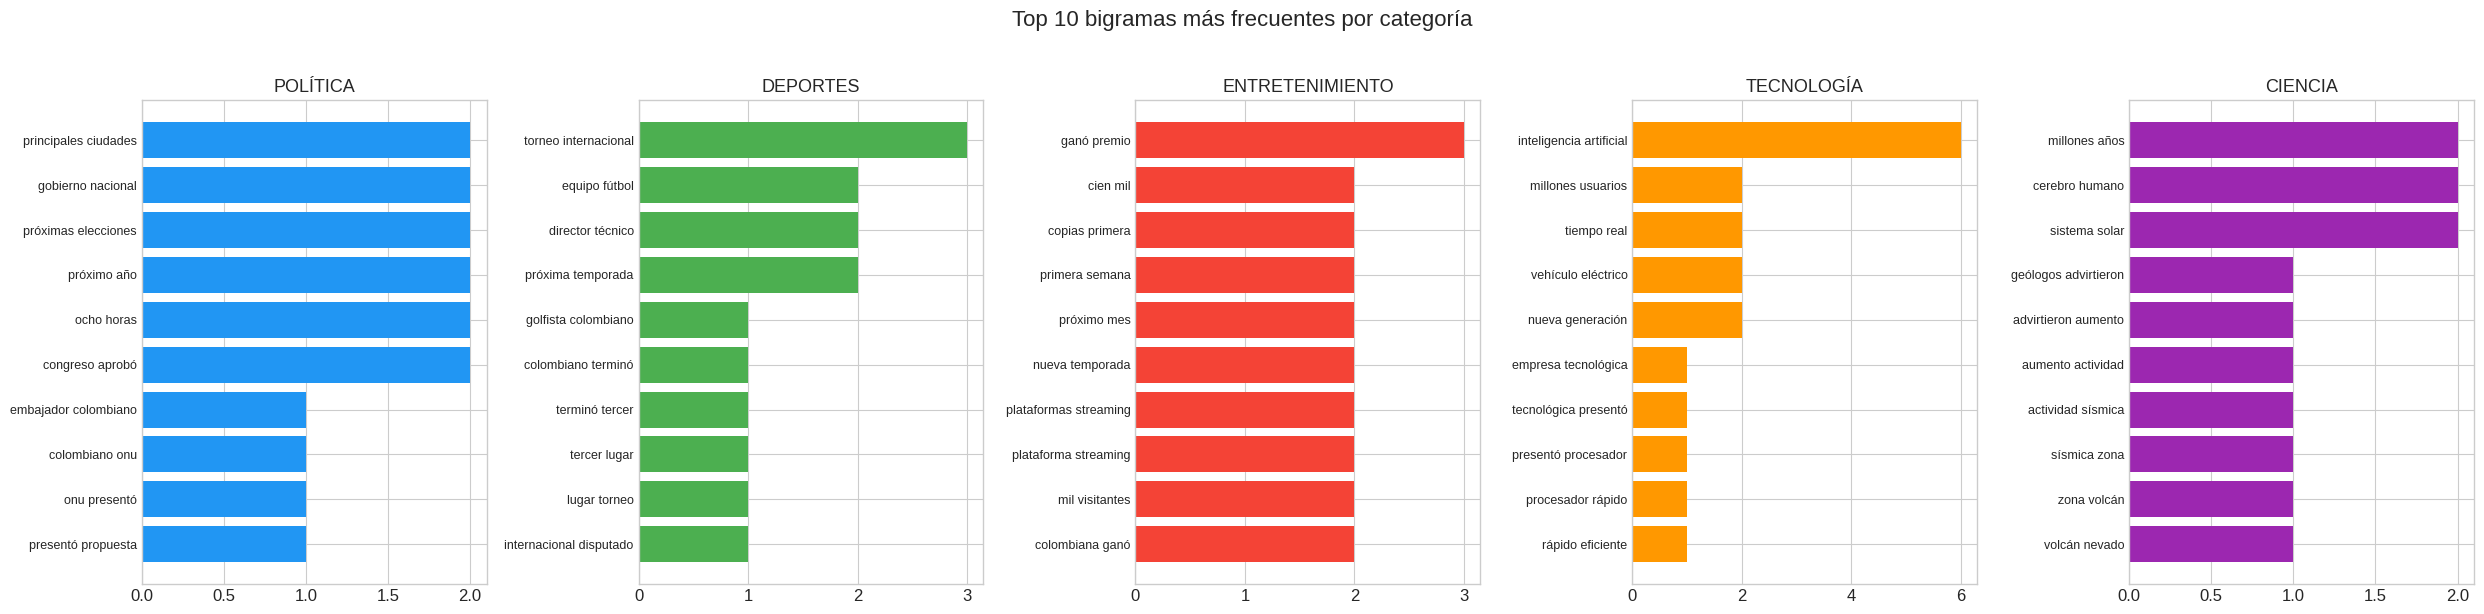

In [160]:
# Visualización de bigramas por categoría

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for idx, cat in enumerate(df['categoria'].unique()):
    textos_cat = df[df['categoria'] == cat]['texto_limpio'].tolist()
    top_bg = obtener_top_ngramas(textos_cat, n=2, top_k=10)

    ngramas_list = [bg[0] for bg in top_bg]
    frecuencias = [bg[1] for bg in top_bg]

    axes[idx].barh(range(len(ngramas_list)), frecuencias, color=colores[idx])
    axes[idx].set_yticks(range(len(ngramas_list)))
    axes[idx].set_yticklabels(ngramas_list, fontsize=9)
    axes[idx].set_title(cat.upper(), fontsize=13)
    axes[idx].invert_yaxis()

plt.suptitle('Top 10 bigramas más frecuentes por categoría', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [161]:
# TF-IDF con bigramas

vectorizer_tfidf_bigram = TfidfVectorizer(
    ngram_range=(1, 2),   # Unigramas Y bigramas
    max_features=1000,
    min_df=2,
    max_df=0.95
)

matriz_tfidf_bigram = vectorizer_tfidf_bigram.fit_transform(df['texto_limpio'])

print(f"Forma de la matriz TF-IDF con bigramas: {matriz_tfidf_bigram.shape}")
print(f"  → ¡Mucho más grande que solo unigramas ({matriz_tfidf.shape[1]} features)!")
print(f"  → Los bigramas capturan contexto local.")

# Top bigramas TF-IDF por categoría
print("\nTOP 8 BIGRAMAS con mayor TF-IDF por categoría:")
print("=" * 60)

vocab_bg = vectorizer_tfidf_bigram.get_feature_names_out()

for cat in df['categoria'].unique():
    indices = df[df['categoria'] == cat].index.tolist()
    tfidf_prom = np.array(matriz_tfidf_bigram[indices].mean(axis=0)).flatten()

    # Filtrar solo bigramas (contienen espacio)
    bigramas_indices = [i for i, v in enumerate(vocab_bg) if ' ' in v]
    bigramas_tfidf = [(vocab_bg[i], tfidf_prom[i]) for i in bigramas_indices]
    bigramas_tfidf.sort(key=lambda x: x[1], reverse=True)

    print(f"\n{cat.upper()}:")
    for bg, score in bigramas_tfidf[:8]:
        print(f"  '{bg}' → TF-IDF: {score:.4f}")

Forma de la matriz TF-IDF con bigramas: (150, 302)
  → ¡Mucho más grande que solo unigramas (266 features)!
  → Los bigramas capturan contexto local.

TOP 8 BIGRAMAS con mayor TF-IDF por categoría:

POLÍTICA:
  'próximas elecciones' → TF-IDF: 0.0290
  'próximo año' → TF-IDF: 0.0276
  'ocho horas' → TF-IDF: 0.0273
  'principales ciudades' → TF-IDF: 0.0265
  'gobierno nacional' → TF-IDF: 0.0256
  'congreso aprobó' → TF-IDF: 0.0234
  'anunció cambios' → TF-IDF: 0.0000
  'cerebro humano' → TF-IDF: 0.0000

DEPORTES:
  'torneo internacional' → TF-IDF: 0.0439
  'equipo fútbol' → TF-IDF: 0.0274
  'director técnico' → TF-IDF: 0.0244
  'próxima temporada' → TF-IDF: 0.0215
  'veinte países' → TF-IDF: 0.0137
  'colombiano ganó' → TF-IDF: 0.0133
  'dos horas' → TF-IDF: 0.0125
  'anunció cambios' → TF-IDF: 0.0103

ENTRETENIMIENTO:
  'ganó premio' → TF-IDF: 0.0363
  'colombiana ganó' → TF-IDF: 0.0251
  'plataformas streaming' → TF-IDF: 0.0249
  'mil visitantes' → TF-IDF: 0.0243
  'plataforma streamin

### Pregunta - Experimento 6

¿Qué información adicional capturan los bigramas que las palabras individuales no pueden capturar? Da un ejemplo concreto del dataset donde un bigrama sea más informativo que las palabras por separado. ¿Por qué crees que la matriz TF-IDF con bigramas tiene muchas más columnas?

*Escribe aquí tu respuesta...*

---

### Experimento 7: Clasificación de texto con BoW/TF-IDF + Red Neuronal (PyTorch)

Ahora vamos a usar las representaciones numéricas que creamos (BoW y TF-IDF) como **entrada a una red neuronal en PyTorch** para clasificar las noticias en categorías.

Este es el puente entre el preprocesamiento de texto clásico y el Deep Learning que aprendimos en las guías anteriores.

In [162]:
# Preparar los datos para PyTorch

# Codificar las categorías como números
categorias_unicas = sorted(df['categoria'].unique())
cat_a_num = {cat: i for i, cat in enumerate(categorias_unicas)}
num_a_cat = {i: cat for cat, i in cat_a_num.items()}

print("Mapeo de categorías:")
for cat, num in cat_a_num.items():
    print(f"  {cat} → {num}")

# Etiquetas numéricas
y = np.array([cat_a_num[c] for c in df['categoria']])
print(f"\nEtiquetas: {y[:20]}...")
print(f"Distribución: {Counter(y)}")

Mapeo de categorías:
  ciencia → 0
  deportes → 1
  entretenimiento → 2
  política → 3
  tecnología → 4

Etiquetas: [3 1 2 3 3 4 3 0 3 3 2 1 4 1 1 4 2 3 4 0]...
Distribución: Counter({np.int64(3): 30, np.int64(1): 30, np.int64(2): 30, np.int64(4): 30, np.int64(0): 30})


In [163]:
# Crear representaciones BoW y TF-IDF para clasificación

# BoW
vectorizer_bow_clf = CountVectorizer(max_features=500, min_df=2, max_df=0.95)
X_bow = vectorizer_bow_clf.fit_transform(df['texto_limpio']).toarray()

# TF-IDF
vectorizer_tfidf_clf = TfidfVectorizer(max_features=500, min_df=2, max_df=0.95)
X_tfidf = vectorizer_tfidf_clf.fit_transform(df['texto_limpio']).toarray()

print(f"Forma X_bow:   {X_bow.shape}")
print(f"Forma X_tfidf: {X_tfidf.shape}")
print(f"Forma y:       {y.shape}")

# División train/test (80/20)
X_bow_train, X_bow_test, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

X_tfidf_train, X_tfidf_test, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_bow_train.shape[0]} muestras")
print(f"Test:  {X_bow_test.shape[0]} muestras")

Forma X_bow:   (150, 266)
Forma X_tfidf: (150, 266)
Forma y:       (150,)

Train: 120 muestras
Test:  30 muestras


In [164]:
# Definir la red neuronal para clasificación de texto

class ClasificadorTexto(nn.Module):
    """
    Red neuronal simple para clasificación de texto.
    Recibe un vector (BoW o TF-IDF) y predice la categoría.

    Arquitectura:
    - Capa de entrada: tamaño del vocabulario (500)
    - Capa oculta 1: 128 neuronas + ReLU + Dropout
    - Capa oculta 2: 64 neuronas + ReLU + Dropout
    - Capa de salida: número de categorías (5)
    """
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, output_dim, dropout=0.3):
        super(ClasificadorTexto, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim2, output_dim)
        )

    def forward(self, x):
        return self.red(x)


# Parámetros
INPUT_DIM = X_bow.shape[1]
HIDDEN_DIM1 = 128
HIDDEN_DIM2 = 64
OUTPUT_DIM = len(categorias_unicas)  # 5 categorías
EPOCHS = 80
LR = 0.001
BATCH_SIZE = 16

print(f"Arquitectura de la red:")
print(f"  Entrada:   {INPUT_DIM} (tamaño del vocabulario)")
print(f"  Oculta 1:  {HIDDEN_DIM1} neuronas")
print(f"  Oculta 2:  {HIDDEN_DIM2} neuronas")
print(f"  Salida:    {OUTPUT_DIM} categorías")
print(f"  Epochs:    {EPOCHS}")
print(f"  Batch:     {BATCH_SIZE}")
print(f"  LR:        {LR}")

Arquitectura de la red:
  Entrada:   266 (tamaño del vocabulario)
  Oculta 1:  128 neuronas
  Oculta 2:  64 neuronas
  Salida:    5 categorías
  Epochs:    80
  Batch:     16
  LR:        0.001


In [165]:
# Función de entrenamiento

def entrenar_modelo(X_train, X_test, y_train, y_test, nombre_repr, epochs=EPOCHS):
    """
    Entrena un modelo de clasificación de texto y retorna métricas.

    Args:
        X_train, X_test: matrices de características (numpy)
        y_train, y_test: etiquetas (numpy)
        nombre_repr: nombre de la representación ('BoW' o 'TF-IDF')
        epochs: número de épocas

    Returns:
        modelo entrenado, historial de pérdidas y exactitudes
    """
    # Convertir a tensores de PyTorch
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.LongTensor(y_train)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.LongTensor(y_test)

    # DataLoader
    dataset_train = TensorDataset(X_train_t, y_train_t)
    loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)

    # Crear modelo
    modelo = ClasificadorTexto(INPUT_DIM, HIDDEN_DIM1, HIDDEN_DIM2, OUTPUT_DIM)
    criterio = nn.CrossEntropyLoss()
    optimizador = optim.Adam(modelo.parameters(), lr=LR)

    # Historial
    historial_loss = []
    historial_acc_train = []
    historial_acc_test = []

    # Entrenamiento
    for epoch in range(epochs):
        modelo.train()
        epoch_loss = 0

        for X_batch, y_batch in loader_train:
            # Forward
            predicciones = modelo(X_batch)
            loss = criterio(predicciones, y_batch)

            # Backward
            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

            epoch_loss += loss.item()

        # Calcular exactitud
        modelo.eval()
        with torch.no_grad():
            # Train accuracy
            pred_train = modelo(X_train_t).argmax(dim=1)
            acc_train = (pred_train == y_train_t).float().mean().item()

            # Test accuracy
            pred_test = modelo(X_test_t).argmax(dim=1)
            acc_test = (pred_test == y_test_t).float().mean().item()

        avg_loss = epoch_loss / len(loader_train)
        historial_loss.append(avg_loss)
        historial_acc_train.append(acc_train)
        historial_acc_test.append(acc_test)

        if (epoch + 1) % 20 == 0:
            print(f"  [{nombre_repr}] Epoch {epoch+1:3d}/{epochs} | "
                  f"Loss: {avg_loss:.4f} | "
                  f"Acc Train: {acc_train:.4f} | "
                  f"Acc Test: {acc_test:.4f}")

    return modelo, historial_loss, historial_acc_train, historial_acc_test


print("Función de entrenamiento definida.")

Función de entrenamiento definida.


In [166]:
# Entrenar modelo con BoW
print("ENTRENAMIENTO CON BOW")
print("=" * 60)
modelo_bow, loss_bow, acc_train_bow, acc_test_bow = entrenar_modelo(
    X_bow_train, X_bow_test, y_train, y_test, 'BoW'
)

print(f"\nMejor exactitud en test (BoW): {max(acc_test_bow):.4f}")

ENTRENAMIENTO CON BOW
  [BoW] Epoch  20/80 | Loss: 0.0738 | Acc Train: 1.0000 | Acc Test: 0.7000
  [BoW] Epoch  40/80 | Loss: 0.0080 | Acc Train: 1.0000 | Acc Test: 0.6667
  [BoW] Epoch  60/80 | Loss: 0.0041 | Acc Train: 1.0000 | Acc Test: 0.6667
  [BoW] Epoch  80/80 | Loss: 0.0038 | Acc Train: 1.0000 | Acc Test: 0.7000

Mejor exactitud en test (BoW): 0.7333


In [167]:
# Entrenar modelo con TF-IDF
print("ENTRENAMIENTO CON TF-IDF")
print("=" * 60)
modelo_tfidf, loss_tfidf, acc_train_tfidf, acc_test_tfidf = entrenar_modelo(
    X_tfidf_train, X_tfidf_test, y_train, y_test, 'TF-IDF'
)

print(f"\nMejor exactitud en test (TF-IDF): {max(acc_test_tfidf):.4f}")

ENTRENAMIENTO CON TF-IDF
  [TF-IDF] Epoch  20/80 | Loss: 0.1579 | Acc Train: 1.0000 | Acc Test: 0.6667
  [TF-IDF] Epoch  40/80 | Loss: 0.0112 | Acc Train: 1.0000 | Acc Test: 0.7000
  [TF-IDF] Epoch  60/80 | Loss: 0.0103 | Acc Train: 1.0000 | Acc Test: 0.7000
  [TF-IDF] Epoch  80/80 | Loss: 0.0024 | Acc Train: 1.0000 | Acc Test: 0.6667

Mejor exactitud en test (TF-IDF): 0.7000


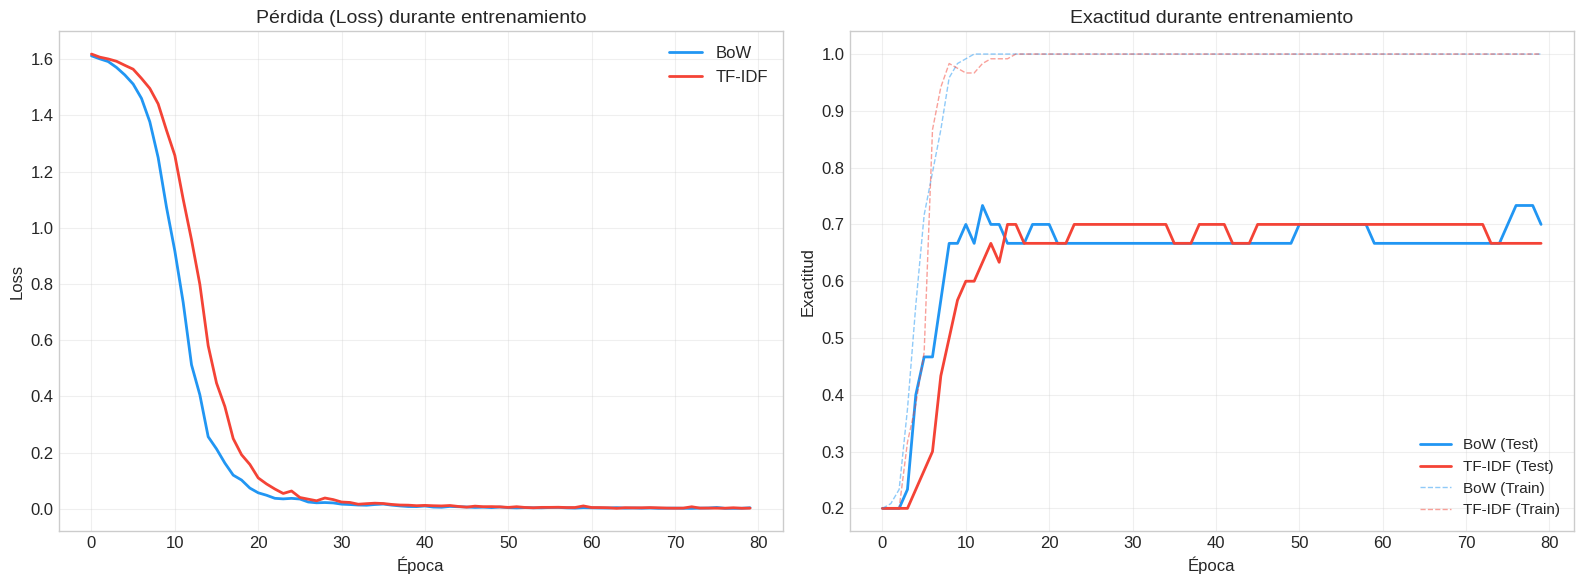


Exactitud final en test:
  BoW:    0.7000
  TF-IDF: 0.6667


In [168]:
# Comparar curvas de aprendizaje

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pérdida
axes[0].plot(loss_bow, label='BoW', color='#2196F3', linewidth=2)
axes[0].plot(loss_tfidf, label='TF-IDF', color='#F44336', linewidth=2)
axes[0].set_title('Pérdida (Loss) durante entrenamiento', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# Exactitud
axes[1].plot(acc_test_bow, label='BoW (Test)', color='#2196F3', linewidth=2)
axes[1].plot(acc_test_tfidf, label='TF-IDF (Test)', color='#F44336', linewidth=2)
axes[1].plot(acc_train_bow, label='BoW (Train)', color='#2196F3', linewidth=1, linestyle='--', alpha=0.5)
axes[1].plot(acc_train_tfidf, label='TF-IDF (Train)', color='#F44336', linewidth=1, linestyle='--', alpha=0.5)
axes[1].set_title('Exactitud durante entrenamiento', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Exactitud')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nExactitud final en test:")
print(f"  BoW:    {acc_test_bow[-1]:.4f}")
print(f"  TF-IDF: {acc_test_tfidf[-1]:.4f}")

In [169]:
# Evaluación detallada: Classification Report y Matriz de Confusión

# Predicciones finales
modelo_bow.eval()
modelo_tfidf.eval()

with torch.no_grad():
    pred_bow = modelo_bow(torch.FloatTensor(X_bow_test)).argmax(dim=1).numpy()
    pred_tfidf = modelo_tfidf(torch.FloatTensor(X_tfidf_test)).argmax(dim=1).numpy()

# Classification Report
print("REPORTE DE CLASIFICACIÓN - BoW")
print("=" * 60)
print(classification_report(y_test, pred_bow, target_names=categorias_unicas))

print("\nREPORTE DE CLASIFICACIÓN - TF-IDF")
print("=" * 60)
print(classification_report(y_test, pred_tfidf, target_names=categorias_unicas))

REPORTE DE CLASIFICACIÓN - BoW
                 precision    recall  f1-score   support

        ciencia       0.40      0.33      0.36         6
       deportes       0.86      1.00      0.92         6
entretenimiento       0.83      0.83      0.83         6
       política       0.75      0.50      0.60         6
     tecnología       0.62      0.83      0.71         6

       accuracy                           0.70        30
      macro avg       0.69      0.70      0.69        30
   weighted avg       0.69      0.70      0.69        30


REPORTE DE CLASIFICACIÓN - TF-IDF
                 precision    recall  f1-score   support

        ciencia       0.25      0.17      0.20         6
       deportes       0.86      1.00      0.92         6
entretenimiento       0.62      0.83      0.71         6
       política       0.75      0.50      0.60         6
     tecnología       0.71      0.83      0.77         6

       accuracy                           0.67        30
      macro avg  

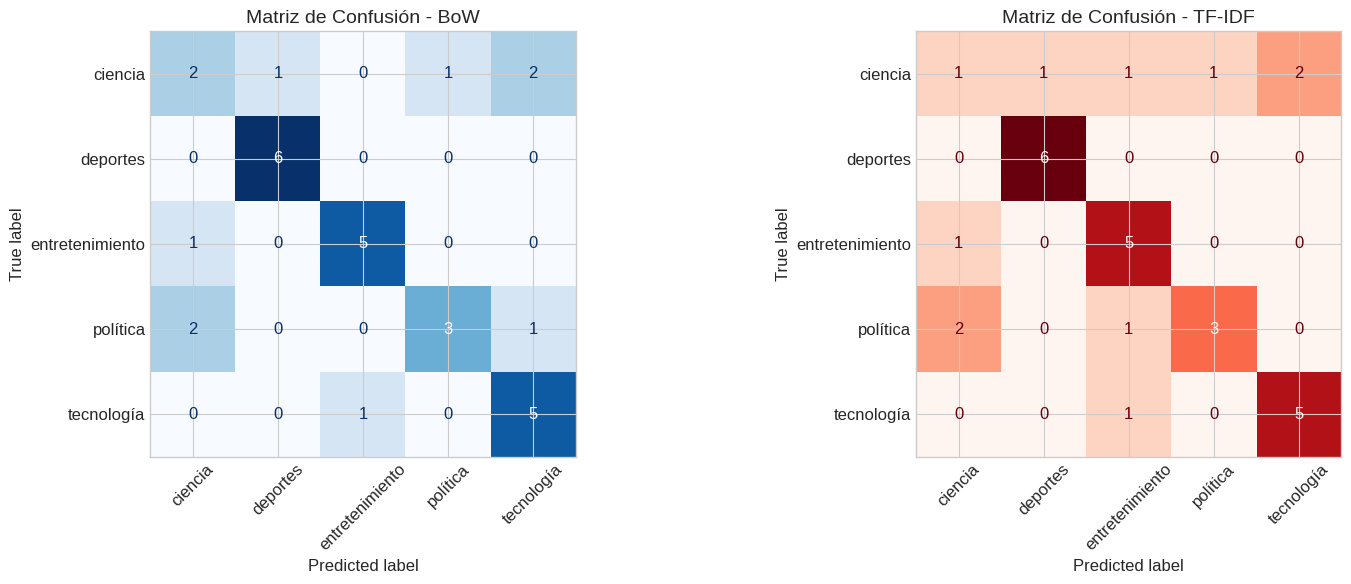

In [170]:
# Matrices de confusión

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BoW
cm_bow = confusion_matrix(y_test, pred_bow)
disp_bow = ConfusionMatrixDisplay(confusion_matrix=cm_bow, display_labels=categorias_unicas)
disp_bow.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión - BoW', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# TF-IDF
cm_tfidf = confusion_matrix(y_test, pred_tfidf)
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=categorias_unicas)
disp_tfidf.plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Matriz de Confusión - TF-IDF', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Pregunta - Experimento 7

¿Cuál representación (BoW vs TF-IDF) dio mejor resultado para la clasificación? ¿Por qué crees que fue así? ¿Qué categorías se confunden más entre sí? ¿Tiene sentido que esas categorías se confundan? Explica.

*Escribe aquí tu respuesta...*

---

### Experimento 8: Limitaciones del enfoque tradicional

Aunque BoW y TF-IDF son útiles, tienen **limitaciones fundamentales** que debemos entender antes de avanzar a técnicas más sofisticadas como los Word Embeddings.

In [171]:
# Demostración de las limitaciones de BoW

print("LIMITACIONES DE BAG OF WORDS Y TF-IDF")
print("=" * 70)

# Limitación 1: Pérdida del orden de las palabras
print("\n1. PÉRDIDA DEL ORDEN DE LAS PALABRAS")
print("-" * 70)

oracion_a = "el gato persiguió al ratón"
oracion_b = "el ratón persiguió al gato"

# Vectorizar ambas
vec_temp = CountVectorizer()
bow_temp = vec_temp.fit_transform([oracion_a, oracion_b])

print(f"  Oración A: '{oracion_a}'")
print(f"  Oración B: '{oracion_b}'")
print(f"\n  Vector BoW A: {bow_temp[0].toarray()[0]}")
print(f"  Vector BoW B: {bow_temp[1].toarray()[0]}")
print(f"  Vocabulario: {vec_temp.get_feature_names_out().tolist()}")
print(f"\n  ¡Los vectores son IDÉNTICOS! Pero el significado es completamente")
print(f"  diferente: en A el gato persigue, en B el ratón persigue.")

LIMITACIONES DE BAG OF WORDS Y TF-IDF

1. PÉRDIDA DEL ORDEN DE LAS PALABRAS
----------------------------------------------------------------------
  Oración A: 'el gato persiguió al ratón'
  Oración B: 'el ratón persiguió al gato'

  Vector BoW A: [1 1 1 1 1]
  Vector BoW B: [1 1 1 1 1]
  Vocabulario: ['al', 'el', 'gato', 'persiguió', 'ratón']

  ¡Los vectores son IDÉNTICOS! Pero el significado es completamente
  diferente: en A el gato persigue, en B el ratón persigue.


In [172]:
# Limitación 2: No captura semántica (sinónimos)
print("2. NO CAPTURA SEMÁNTICA (SINÓNIMOS)")
print("-" * 70)

oracion_c = "el carro es veloz"
oracion_d = "el automóvil es rápido"
oracion_e = "la mesa es grande"

vec_temp2 = CountVectorizer()
bow_temp2 = vec_temp2.fit_transform([oracion_c, oracion_d, oracion_e])

print(f"  Oración C: '{oracion_c}'")
print(f"  Oración D: '{oracion_d}' (mismo significado que C)")
print(f"  Oración E: '{oracion_e}' (significado diferente)")
print(f"\n  Vocabulario: {vec_temp2.get_feature_names_out().tolist()}")
print(f"  Vector BoW C: {bow_temp2[0].toarray()[0]}")
print(f"  Vector BoW D: {bow_temp2[1].toarray()[0]}")
print(f"  Vector BoW E: {bow_temp2[2].toarray()[0]}")

# Calcular similitud coseno
from sklearn.metrics.pairwise import cosine_similarity
sim_cd = cosine_similarity(bow_temp2[0], bow_temp2[1])[0][0]
sim_ce = cosine_similarity(bow_temp2[0], bow_temp2[2])[0][0]

print(f"\n  Similitud coseno C↔D (mismo significado): {sim_cd:.4f}")
print(f"  Similitud coseno C↔E (distinto significado): {sim_ce:.4f}")
print(f"\n  ¡C y D deberían ser similares, pero BoW dice que son tan")
print(f"  diferentes como C y E! No entiende que 'carro'='automóvil'.")

2. NO CAPTURA SEMÁNTICA (SINÓNIMOS)
----------------------------------------------------------------------
  Oración C: 'el carro es veloz'
  Oración D: 'el automóvil es rápido' (mismo significado que C)
  Oración E: 'la mesa es grande' (significado diferente)

  Vocabulario: ['automóvil', 'carro', 'el', 'es', 'grande', 'la', 'mesa', 'rápido', 'veloz']
  Vector BoW C: [0 1 1 1 0 0 0 0 1]
  Vector BoW D: [1 0 1 1 0 0 0 1 0]
  Vector BoW E: [0 0 0 1 1 1 1 0 0]

  Similitud coseno C↔D (mismo significado): 0.5000
  Similitud coseno C↔E (distinto significado): 0.2500

  ¡C y D deberían ser similares, pero BoW dice que son tan
  diferentes como C y E! No entiende que 'carro'='automóvil'.


In [173]:
# Limitación 3: Dimensionalidad alta y dispersión
print("3. ALTA DIMENSIONALIDAD Y DISPERSIÓN (SPARSITY)")
print("-" * 70)

# Analizar la dispersión de nuestra matriz BoW
total_elementos = matriz_bow.shape[0] * matriz_bow.shape[1]
elementos_no_cero = matriz_bow.nnz  # número de no-ceros
dispersión = (1 - elementos_no_cero / total_elementos) * 100

print(f"  Tamaño de la matriz BoW: {matriz_bow.shape}")
print(f"  Total de elementos: {total_elementos:,}")
print(f"  Elementos no-cero: {elementos_no_cero:,}")
print(f"  Elementos cero: {total_elementos - elementos_no_cero:,}")
print(f"  Dispersión (sparsity): {dispersión:.1f}%")
print(f"\n  ¡El {dispersión:.1f}% de la matriz son ceros!")
print(f"  Esto es ineficiente en memoria y puede dificultar el aprendizaje.")

3. ALTA DIMENSIONALIDAD Y DISPERSIÓN (SPARSITY)
----------------------------------------------------------------------
  Tamaño de la matriz BoW: (150, 266)
  Total de elementos: 39,900
  Elementos no-cero: 869
  Elementos cero: 39,031
  Dispersión (sparsity): 97.8%

  ¡El 97.8% de la matriz son ceros!
  Esto es ineficiente en memoria y puede dificultar el aprendizaje.


In [174]:
# Limitación 4: Negación y contexto
print("4. NO CAPTURA NEGACIÓN NI CONTEXTO")
print("-" * 70)

oracion_f = "esta película es buena"
oracion_g = "esta película no es buena"  # Significado opuesto

vec_temp3 = CountVectorizer()
bow_temp3 = vec_temp3.fit_transform([oracion_f, oracion_g])

print(f"  Oración F: '{oracion_f}' → Positiva")
print(f"  Oración G: '{oracion_g}' → Negativa")
print(f"\n  Vocabulario: {vec_temp3.get_feature_names_out().tolist()}")
print(f"  Vector BoW F: {bow_temp3[0].toarray()[0]}")
print(f"  Vector BoW G: {bow_temp3[1].toarray()[0]}")

sim_fg = cosine_similarity(bow_temp3[0], bow_temp3[1])[0][0]
print(f"\n  Similitud coseno F↔G: {sim_fg:.4f}")
print(f"  ¡Altísima similitud a pesar de tener significado OPUESTO!")
print(f"  La diferencia es solo una palabra ('no'), pero cambia todo.")

print("\n" + "=" * 70)
print("\nRESUMEN DE LIMITACIONES:")
print("  1. Pierde el ORDEN de las palabras")
print("  2. No entiende SINÓNIMOS ni relaciones semánticas")
print("  3. Matrices muy DISPERSAS y de alta dimensionalidad")
print("  4. No captura NEGACIÓN ni contexto")
print("  5. No entiende POLISEMIA (misma palabra, diferente significado)")
print("\n→ Estas limitaciones nos motivan a buscar representaciones")
print("  más sofisticadas: ¡Word Embeddings! (Guía 10)")

4. NO CAPTURA NEGACIÓN NI CONTEXTO
----------------------------------------------------------------------
  Oración F: 'esta película es buena' → Positiva
  Oración G: 'esta película no es buena' → Negativa

  Vocabulario: ['buena', 'es', 'esta', 'no', 'película']
  Vector BoW F: [1 1 1 0 1]
  Vector BoW G: [1 1 1 1 1]

  Similitud coseno F↔G: 0.8944
  ¡Altísima similitud a pesar de tener significado OPUESTO!
  La diferencia es solo una palabra ('no'), pero cambia todo.


RESUMEN DE LIMITACIONES:
  1. Pierde el ORDEN de las palabras
  2. No entiende SINÓNIMOS ni relaciones semánticas
  3. Matrices muy DISPERSAS y de alta dimensionalidad
  4. No captura NEGACIÓN ni contexto
  5. No entiende POLISEMIA (misma palabra, diferente significado)

→ Estas limitaciones nos motivan a buscar representaciones
  más sofisticadas: ¡Word Embeddings! (Guía 10)


### Pregunta - Experimento 8

¿Qué información del texto se pierde con BoW y TF-IDF? Describe al menos 3 limitaciones con ejemplos propios (diferentes a los mostrados). ¿Cómo crees que se podría capturar el significado semántico de las palabras? ¿Qué propiedades debería tener una representación ideal de palabras?

*Escribe aquí tu respuesta...*

---

## 5. Síntesis y reflexión

Responde las siguientes preguntas de forma detallada.

### Pregunta de síntesis 1

Describe el **pipeline completo de preprocesamiento de texto** que usarías para un proyecto real de clasificación de noticias. Incluye cada paso, las herramientas/funciones que usarías y justifica tus decisiones (por ejemplo, ¿usarías stemming o lematización? ¿eliminarías stopwords? ¿BoW o TF-IDF?).

*Escribe aquí tu respuesta...*

### Pregunta de síntesis 2

¿Cuáles son las **limitaciones principales** de representar texto con BoW/TF-IDF? Menciona al menos 4 limitaciones y da un ejemplo concreto de cada una.

*Escribe aquí tu respuesta...*

---

## 6. Reto extra: Mini-clasificador de sentimiento

### Instrucciones:

1. **Recopila 30 textos** escritos por ti mismo (reseñas de productos, comentarios sobre películas, opiniones sobre restaurantes, etc.):
   - 10 textos con sentimiento **positivo**
   - 10 textos con sentimiento **negativo**
   - 10 textos con sentimiento **neutro**

2. **Aplica el pipeline completo** de preprocesamiento:
   - Limpieza de texto
   - Eliminación de stopwords
   - Representación TF-IDF

3. **Entrena un clasificador** con TF-IDF + Red Neuronal en PyTorch

4. **Evalúa** el rendimiento y analiza los errores

> **Nota**: Con solo 30 textos el modelo no será muy preciso, pero el objetivo es practicar el pipeline completo.

In [175]:
# RETO EXTRA: Mini-clasificador de sentimiento
# Completa el código a continuación

# Paso 1: Define tus 30 textos
textos_positivos = [
    # Escribe aquí 10 textos positivos (reseñas, comentarios, opiniones)
    "Escribe aquí tu texto positivo 1",
    "Escribe aquí tu texto positivo 2",
    # ... completa hasta 10
]

textos_negativos = [
    # Escribe aquí 10 textos negativos
    "Escribe aquí tu texto negativo 1",
    "Escribe aquí tu texto negativo 2",
    # ... completa hasta 10
]

textos_neutros = [
    # Escribe aquí 10 textos neutros
    "Escribe aquí tu texto neutro 1",
    "Escribe aquí tu texto neutro 2",
    # ... completa hasta 10
]

# Paso 2: Construir el dataset
# textos_sentimiento = textos_positivos + textos_negativos + textos_neutros
# etiquetas_sentimiento = ['positivo']*10 + ['negativo']*10 + ['neutro']*10

# Paso 3: Aplicar pipeline de preprocesamiento
# textos_limpios = [limpiar_texto(t) for t in textos_sentimiento]

# Paso 4: Representación TF-IDF
# vectorizer_sent = TfidfVectorizer(max_features=200)
# X_sent = vectorizer_sent.fit_transform(textos_limpios).toarray()

# Paso 5: Entrenar modelo PyTorch
# (Adapta el código del Experimento 7)

# Paso 6: Evaluar
# (Usa classification_report y confusion_matrix)

print("Completa este reto con tus propios textos.")

Completa este reto con tus propios textos.


---

## 7. Referencias y recursos adicionales

### Documentación oficial
- [NLTK Documentation](https://www.nltk.org/) - Biblioteca de PLN para Python
- [scikit-learn: Text Feature Extraction](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction) - CountVectorizer y TfidfVectorizer
- [WordCloud Documentation](https://amueller.github.io/word_cloud/) - Generación de nubes de palabras

### Libros y tutoriales
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media. [Disponible gratuitamente en nltk.org/book](https://www.nltk.org/book/)
- Jurafsky, D., & Martin, J. H. (2023). *Speech and Language Processing* (3rd ed.). [Disponible gratuitamente](https://web.stanford.edu/~jurafsky/slp3/)
- Manning, C. D., Raghavan, P., & Schutze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press. [Capítulos sobre TF-IDF](https://nlp.stanford.edu/IR-book/)

### Artículos fundamentales
- Sparck Jones, K. (1972). "A statistical interpretation of term specificity and its application in retrieval." *Journal of Documentation*, 28(1), 11-21. (Artículo original sobre IDF)

### Próxima guía
- **Guía 10: Word Embeddings (Word2Vec, GloVe)** - Representaciones densas de palabras que capturan significado semántico

---

*Guía 09 de 14 - Electiva II: Deep Learning - Tecnológico de Antioquia - 2026-1*